# Sample ML Model Code
Lucille Gagnon
##### adapted from DSML project to get us started with mdoel evaluation

In [1]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn import linear_model
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
os.getcwd()

'/home/jovyan/work/ESDA_FinalProj_GalvestonBay'

In [2]:
os.chdir('/shared_space/Galveston_Bay')   


In [3]:
#load in samples.csv and targets.csv as X and y, respectively
# use X header to set feature_names
X_og = pd.read_csv('/shared_space/Galveston_Bay/samples.csv')
y = pd.read_csv('/shared_space/Galveston_Bay/targets.csv')
feature_names = X_og.columns
feature_names

Index(['u10', ' v10', ' wind_speed', ' ssr', ' t2m', ' modis_time_diff_min',
       ' red', ' nir', ' red_over_nir', ' ndvi', ' modis_blue', ' modis_green',
       ' modis_chlor', ' lat', ' lon', ' year', ' month', ' dayofyear'],
      dtype='object')

dropped columns that may add noise to the models

In [4]:
dropped_columns = [' modis_time_diff_min', ' lat', ' lon', ' red_over_nir', ' year', ' wind_speed', ' month']
X = X_og.drop(columns = dropped_columns)
print(np.shape(X))
X.head()
feature_names = X.columns
feature_names

(1614, 11)


Index(['u10', ' v10', ' ssr', ' t2m', ' red', ' nir', ' ndvi', ' modis_blue',
       ' modis_green', ' modis_chlor', ' dayofyear'],
      dtype='object')

In [5]:
#maybe explore observation stats?
X.describe()

,u10,v10,ssr,t2m,red,nir,ndvi,modis_blue,modis_green,modis_chlor,dayofyear
count,1614.000000,1614.000000,1614.000000,1614.000000,1614.000000,1614.000000,1614.000000,1614.000000,1614.000000,1614.000000,1614.000000
mean,0.198693,0.723222,292.832088,3.423631,0.240384,0.235341,0.151202,0.226177,0.251252,0.762912,178.171623
std,1.782633,2.975909,7.885628,0.931457,0.241783,0.246974,0.313992,0.248966,0.240251,0.206052,100.405210
min,-4.680000,-5.660000,275.130000,0.310000,0.010000,0.000000,-0.700000,0.000000,0.020000,0.030000,6.000000
25%,-1.400000,-1.750000,287.240000,2.720000,0.060000,0.020000,-0.010000,0.050000,0.080000,0.620000,79.000000
50%,0.710000,1.960000,295.150000,3.440000,0.140000,0.150000,0.070000,0.110000,0.140000,0.780000,162.000000
75%,1.750000,3.200000,300.120000,4.080000,0.340000,0.347500,0.400000,0.320000,0.350000,0.940000,255.000000
max,3.810000,5.590000,302.260000,5.970000,0.860000,0.890000,0.950000,0.880000,0.880000,1.050000,354.000000


In [6]:
y.describe()

,ground_obs
count,1614.000000
mean,5.775638
std,1.645328
min,2.490000
25%,4.220000
50%,6.285000
75%,7.040000
max,9.490000


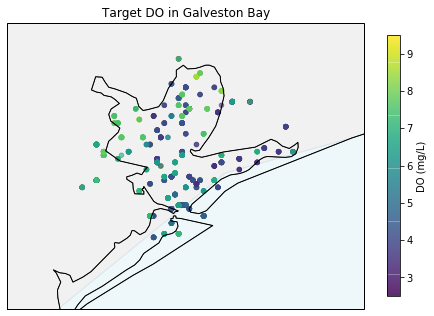

In [18]:
# #explore locations of target points
# plt.figure(figsize=(8, 6))
# plt.scatter(X_og[' lat'], X_og[' lon'], c=y['ground_obs'], cmap='viridis',alpha=0.5)
# plt.colorbar(label= 'DO (mgL)')
# plt.title('Target DO in the Gavleston Bay')
# plt.show()

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Create a map with PlateCarree (lat/lon) projection
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add coastline (Cartopy’s built-in)
ax.coastlines(resolution='10m')

# Optional: add state boundaries for clarity
ax.add_feature(cfeature.STATES.with_scale('10m'), linewidth=0.5)

# Optional: add land/water shading
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2)

# Plot your points
sc = ax.scatter(
    X_og[' lon'], X_og[' lat'],   # lon = x, lat = y
    c=y['ground_obs'],
    cmap='viridis',
    alpha=0.6,
    s=20,
    transform=ccrs.PlateCarree()
)

plt.colorbar(sc, label='DO (mg/L)', shrink=0.8)
plt.title('Target DO in Galveston Bay')

# Zoom into Texas coast (adjust as needed)
#ax.set_extent([-97.5, -94.0, 28.0, 30.5], crs=ccrs.PlateCarree())
ax.set_extent([-95.3, -94.3, 29.1, 29.9], crs=ccrs.PlateCarree())


plt.show()


In [88]:
# #plot heatmap
# corr = np.corrcoef(X, rowvar=False)
# plt.figure(figsize = (8,8), dpi =300)
# sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
#             xticklabels=feature_names, yticklabels=feature_names, vmin=-1, vmax = 1,
#             annot_kws={"ha": "center", "va": "center"}  # center text horizontally & vertically
#             cbar_kws={"shrink": 0.8} 
# )
# #plt.title("Feature Correlation Heatmap")
# plt.tight_layout()
# plt.show()
# corr_BS = corr

In [ ]:
## Model 1: Penalized Regression (Ridge, Lasso)

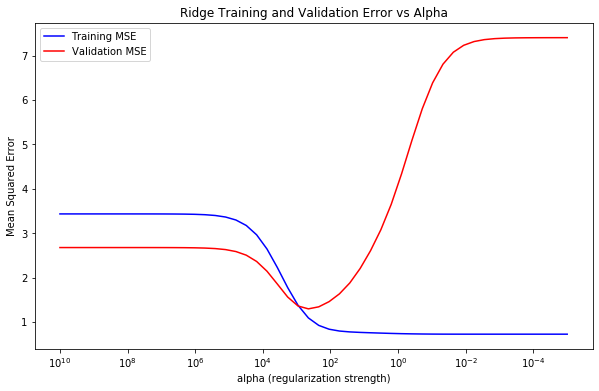

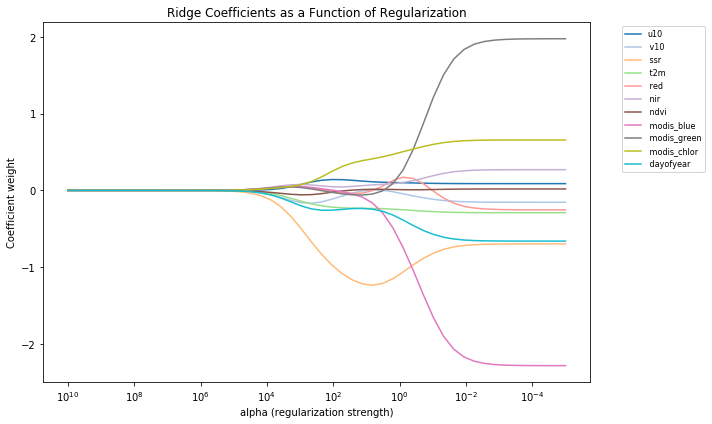

In [20]:
# define alpha range and cross-validation
alphas = np.logspace(-5, 10, 50)
#n_splits = 10
n_splits = 5
#test_size = 480  # ≈20 days
tscv = TimeSeriesSplit(n_splits=n_splits)

#tscv = TimeSeriesSplit(n_splits=n_splits)

# initialize arrays
coefs = np.zeros((len(alphas), X.shape[1]))
mse_train_ridge = np.zeros(len(alphas))
mse_valid_ridge = np.zeros(len(alphas))

# loop over alphas
for j, alpha in enumerate(alphas):
    #initialize lisst for coefs, mse
    fold_coefs = np.zeros((n_splits, X.shape[1]))
    fold_train_mse = []
    fold_valid_mse = []

    #loop through splits
    for i, (train_index, valid_index) in enumerate(tscv.split(X)):
        #extract train/valid data
        X_train, X_valid = X.iloc[train_index], X.iloc[valid_index]
        y_train, y_valid = y.iloc[train_index], y.iloc[valid_index]
        

        # define pipeline
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('ridge', Ridge(alpha=alpha, max_iter=10000))
        ])

        # fit on training data
        pipe.fit(X_train, y_train)
        #make predictions on training and validaiton set
        y_pred_train = pipe.predict(X_train)
        y_pred_valid = pipe.predict(X_valid)

        # store metrics
        fold_train_mse.append(mean_squared_error(y_train, y_pred_train))
        fold_valid_mse.append(mean_squared_error(y_valid, y_pred_valid))
        #extract coefs
        fold_coefs[i, :] = pipe.named_steps['ridge'].coef_

    # average over folds
    mse_train_ridge[j] = np.mean(fold_train_mse)
    mse_valid_ridge[j] = np.mean(fold_valid_mse)
    coefs[j, :] = np.mean(fold_coefs, axis=0)

# plot MSE vs alpha 
plt.figure(figsize=(10, 6))
ax = plt.gca()
plt.plot(alphas, mse_train_ridge, 'b', label='Training MSE')
plt.plot(alphas, mse_valid_ridge, 'r', label='Validation MSE')
ax.set_xscale('log')
ax.set_xlim(ax.get_xlim()[::-1])
plt.xlabel('alpha (regularization strength)')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.title('Ridge Training and Validation Error vs Alpha')
plt.show()

# plot coefficient paths
colors = plt.get_cmap('tab20')
plt.figure(figsize=(10, 6))
ax = plt.gca()
for i, name in enumerate(feature_names):
    color = colors(i / len(feature_names))
    plt.plot(alphas, coefs[:, i], label=name, color=color)

ax.set_xscale('log')
ax.set_xlim(ax.get_xlim()[::-1])
plt.xlabel('alpha (regularization strength)')
plt.ylabel('Coefficient weight')
plt.title('Ridge Coefficients as a Function of Regularization')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


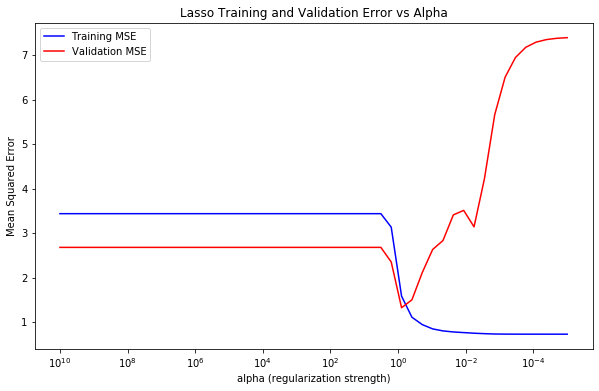

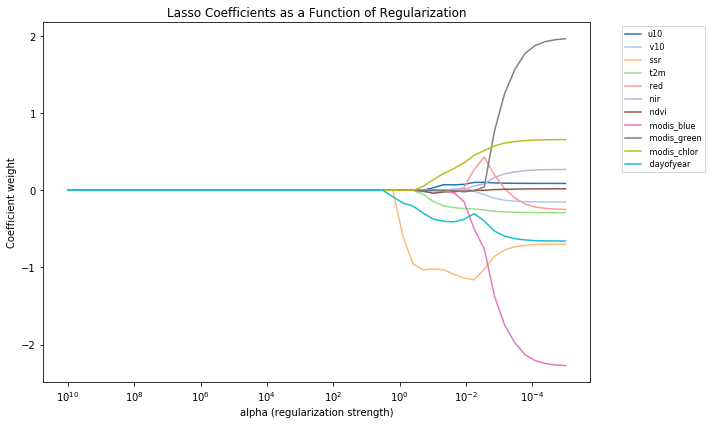

In [21]:
# define alpha range and cross-validation
alphas = np.logspace(-5, 10, 50)

#tscv = TimeSeriesSplit(n_splits=n_splits)
tscv = TimeSeriesSplit(n_splits=n_splits)
# initialize arrays
coefs = np.zeros((len(alphas), X.shape[1]))
mse_train_lasso = np.zeros(len(alphas))
mse_valid_lasso = np.zeros(len(alphas))

# loop over alphas
for j, alpha in enumerate(alphas):
    fold_coefs = np.zeros((n_splits, X.shape[1]))
    fold_train_mse = []
    fold_valid_mse = []


    for i, (train_index, valid_index) in enumerate(tscv.split(X)):
        X_train, X_valid = X.iloc[train_index], X.iloc[valid_index]
        y_train, y_valid = y.iloc[train_index], y.iloc[valid_index]

        # define pipeline
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('lasso', Lasso(alpha=alpha, max_iter=10000))
        ])

        # fit on training data
        pipe.fit(X_train, y_train)
        y_pred_train = pipe.predict(X_train)
        y_pred_valid = pipe.predict(X_valid)

        # store metrics
        fold_train_mse.append(mean_squared_error(y_train, y_pred_train))
        fold_valid_mse.append(mean_squared_error(y_valid, y_pred_valid))
        fold_coefs[i, :] = pipe.named_steps['lasso'].coef_

    # average over folds
    mse_train_lasso[j] = np.mean(fold_train_mse)
    mse_valid_lasso[j] = np.mean(fold_valid_mse)
    coefs[j, :] = np.mean(fold_coefs, axis=0)

# plot MSE vs alpha
plt.figure(figsize=(10, 6))
ax = plt.gca()
plt.plot(alphas, mse_train_lasso, 'b', label='Training MSE')
plt.plot(alphas, mse_valid_lasso, 'r', label='Validation MSE')
ax.set_xscale('log')
ax.set_xlim(ax.get_xlim()[::-1])
plt.xlabel('alpha (regularization strength)')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.title('Lasso Training and Validation Error vs Alpha')
plt.show()

# plot coefficient paths
colors = plt.get_cmap('tab20')
plt.figure(figsize=(10, 6))
ax = plt.gca()
for i, name in enumerate(feature_names):
    color = colors(i / len(feature_names))
    plt.plot(alphas, coefs[:, i], label=name, color=color)

ax.set_xscale('log')
ax.set_xlim(ax.get_xlim()[::-1])
plt.xlabel('alpha (regularization strength)')
plt.ylabel('Coefficient weight')
plt.title('Lasso Coefficients as a Function of Regularization')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


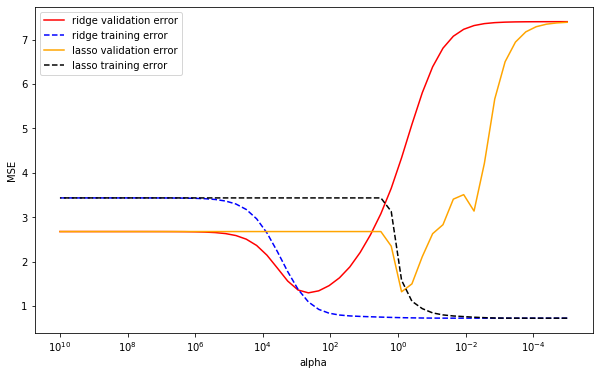

Lasso Validation RMSE = 1.1498967329990837
[0.79060432]


In [22]:
#plot
fig=plt.figure(figsize=[10,6])
ax = plt.gca()
#plot ridge error
plt.plot(alphas, mse_valid_ridge, 'r', label = 'ridge validation error')
plt.plot(alphas, mse_train_ridge, 'b--',  label = 'ridge training error')
#plot lasso error
plt.plot(alphas, mse_valid_lasso, 'orange', label = 'lasso validation error')
plt.plot(alphas, mse_train_lasso, 'k--',  label = 'lasso training error')
#plot properties
ax.set_xscale('log')
ax.set_xlim(ax.get_xlim()[::-1])  # reverse axis
plt.xlabel('alpha')
plt.ylabel('MSE')
plt.axis('tight')
plt.legend()
plt.show()
min_val_mse = min(mse_valid_lasso)
print(f'Lasso Validation RMSE = {np.sqrt(min_val_mse)}')
min_val_mse_idx = np.where(mse_valid_lasso == min_val_mse)[0]
print(alphas[min_val_mse_idx])

In [ ]:
### Model 2: Support Vector Regression

In [23]:
# imports
#from scipy.stats import loguniform
from sklearn.svm import SVR
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, GridSearchCV, cross_validate
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score

# reproducibility
RANDOM_STATE = 42

# time series CV
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

# pipeline (keep consistent step names)
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

# broad randomized search space
param_dist = {
    'svr__kernel': ['rbf', 'linear'],
    'svr__C': np.logspace(-2, 3, 20),       # 1e-2 to 1e3
    'svr__epsilon': np.logspace(-4, -1, 10),# 1e-4 to 1e-1
    'svr__gamma': np.logspace(-4, 1, 15),   # 1e-4 to 1e1
    'svr__degree': [2, 3]
}

rs = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=20,                       # adjust for compute budget
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2,
    random_state=RANDOM_STATE,
    refit=True
)

# run randomized search
rs.fit(X, y)
print("Random search best params:", rs.best_params_)
print("Random search best CV RSME:", np.sqrt(-rs.best_score_))

# build small deterministic grid around best numeric values (only when numeric)
best = rs.best_params_.copy()

# helper to safely get numeric floats (if present)
def _get_float(d, key, fallback, factor_low=0.5, factor_high=5.0, num=6):
    val = d.get(key)
    if val is None:
        return np.logspace(np.log10(fallback*factor_low), np.log10(fallback*factor_high), num)
    try:
        v = float(val)
        return np.linspace(v*factor_low, v*factor_high, num)
    except Exception:
        return [val]

grid = {
    'svr__kernel': [best['svr__kernel']],
    'svr__C': _get_float(best, 'svr__C', 1.0, num=8),
    'svr__epsilon': _get_float(best, 'svr__epsilon', 1e-3, num=6)
}

gs = GridSearchCV(
    estimator=pipe,
    param_grid=grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    refit=True
)

gs.fit(X, y)
print("Grid-refined best params:", gs.best_params_)
print("Grid-refined best CV RMSE:", np.sqrt(-gs.best_score_))

# final evaluation with cross_validate (gives per-fold metrics cleanly)
scoring = {
    'rmse': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred))),
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

cv_res = cross_validate(gs.best_estimator_, X, y, cv=tscv, scoring=scoring, return_train_score=True, n_jobs=-1)

# convert/print readable metrics
def _summ(metric, sign_adjust=False):
    vals = cv_res[metric]
    if sign_adjust: vals = -vals
    return vals.mean(), vals.std()

svr_rmse_mean, svr_rmse_std = _summ('test_rmse')
svr_mae_mean, svr_mae_std   = _summ('test_mae', sign_adjust=True)
svr_r2_mean, svr_r2_std     = _summ('test_r2')

print(f"Final (CV) RMSE: {svr_rmse_mean:.4f} ± {svr_rmse_std:.4f}")
print(f"Final (CV) MAE:  {svr_mae_mean:.4f} ± {svr_mae_std:.4f}")
print(f"Final (CV) R2:   {svr_r2_mean:.4f} ± {svr_r2_std:.4f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.3min finished
/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:724: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


Random search best params: {'svr__kernel': 'rbf', 'svr__gamma': 0.0005179474679231213, 'svr__epsilon': 0.00021544346900318845, 'svr__degree': 3, 'svr__C': 2.3357214690901213}
Random search best CV RSME: 1.2509540994488253
Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:    2.6s finished
/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:724: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Grid-refined best params: {'svr__C': 1.1678607345450607, 'svr__epsilon': 0.00030162085660446385, 'svr__kernel': 'rbf'}
Grid-refined best CV RMSE: 1.3590764626717637
Final (CV) RMSE: 1.3095 ± 0.3639
Final (CV) MAE:  1.0236 ± 0.3938
Final (CV) R2:   -0.7989 ± 0.9362


without lat, lon, year, month, dayofyear as features: the RMSE= 3.039, MAE=2.4, R2= -0.916

In [32]:
### Model 3: Random Forest Regressor

In [19]:
# imports
from scipy.stats import randint, uniform
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, GridSearchCV, cross_validate
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score

# reproducibility
RANDOM_STATE = 42

# time-series CV
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

# pipeline - scaler is optional for RF; left out to keep it minimal (add if you like)
pipe = Pipeline([('rfr', RandomForestRegressor(random_state=RANDOM_STATE))])

# randomized search space
param_dist = {
    'rfr__n_estimators': randint(100, 500),
    'rfr__max_depth': randint(3, 30),
    'rfr__min_samples_split': randint(2, 10),
    'rfr__min_samples_leaf': randint(1, 6),
    'rfr__max_features': uniform(0.3, 0.7),  # draws in [0.3, 1.0)
    'rfr__bootstrap': [True, False]
}

rs = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=40,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2,
    random_state=RANDOM_STATE,
    refit=True
)

# run random search
rs.fit(X, y)
print("Random search best params:", rs.best_params_)
print("Random search best CV RMSE:", np.sqrt(-rs.best_score_))

# --- build a sane grid around numeric best values ---
best = rs.best_params_.copy()

def _make_linear_space(val, low_factor=0.7, high_factor=1.3, num=5, min_val=None, max_val=None):
    """Return a small linspace around val; if val is not float/int, return [val]."""
    try:
        v = float(val)
    except Exception:
        return [val]
    lo, hi = v * low_factor, v * high_factor
    if min_val is not None: lo = max(lo, min_val)
    if max_val is not None: hi = min(hi, max_val)
    if lo == hi:
        return [v]
    # if integer-like parameters, cast to int and unique
    if abs(v - round(v)) < 1e-6:
        arr = np.linspace(int(max(1, round(lo))), int(round(hi)), num, dtype=int)
        return sorted(set(arr))
    return np.linspace(lo, hi, num)

grid = {
    'rfr__n_estimators': _make_linear_space(best.get('rfr__n_estimators', 200), low_factor=0.8, high_factor=1.25, num=5, min_val=50),
    'rfr__max_depth': _make_linear_space(best.get('rfr__max_depth', 10), low_factor=0.7, high_factor=1.3, num=5, min_val=2),
    'rfr__min_samples_split': _make_linear_space(best.get('rfr__min_samples_split', 2), low_factor=0.6, high_factor=1.5, num=4, min_val=2),
    'rfr__min_samples_leaf': _make_linear_space(best.get('rfr__min_samples_leaf', 1), low_factor=0.5, high_factor=2.0, num=4, min_val=1),
    # max_features must be in (0,1] if float; clamp to reasonable range
    'rfr__max_features': np.unique(np.clip(_make_linear_space(best.get('rfr__max_features', 0.5), low_factor=0.8, high_factor=1.1, num=4, min_val=0.01, max_val=1.0), 0.01, 1.0)).tolist(),
    'rfr__bootstrap': [best.get('rfr__bootstrap', True)]
}

# Grid search
gs = GridSearchCV(
    estimator=pipe,
    param_grid=grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    refit=True
)

gs.fit(X, y)
print("Grid-refined best params:", gs.best_params_)
print("Grid-refined best CV RMSE:", np.sqrt(-gs.best_score_))

# final evaluation using cross_validate to get per-fold stats
scoring = {
    'rmse': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred))),
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

cv_res = cross_validate(gs.best_estimator_, X, y, cv=tscv, scoring=scoring, return_train_score=True, n_jobs=-1)

def mean_std(key, sign_adjust=False):
    vals = cv_res[key]
    if sign_adjust:
        vals = -vals
    return vals.mean(), vals.std()

rf_rmse_mean, rf_rmse_std = mean_std('test_rmse')
rf_mae_mean, rf_mae_std   = mean_std('test_mae', sign_adjust=True)
rf_r2_mean, rf_r2_std     = mean_std('test_r2')

print(f"Final (CV) RMSE: {rf_rmse_mean:.4f} ± {rf_rmse_std:.4f}")
print(f"Final (CV) MAE:  {rf_mae_mean:.4f} ± {rf_mae_std:.4f}")
print(f"Final (CV) R2:   {rf_r2_mean:.4f} ± {rf_r2_std:.4f}")

# show training error if you care
train_rmse_mean, train_rmse_std = cv_res['train_rmse'].mean(), cv_res['train_rmse'].std()
print(f"Train RMSE (CV folds): {train_rmse_mean:.4f} ± {train_rmse_std:.4f}")

# feature importances from the fitted estimator (GridSearch refit)
final_rfr = gs.best_estimator_.named_steps['rfr']
if hasattr(final_rfr, 'feature_importances_'):
    importances = final_rfr.feature_importances_
    # show top 10 features (if X is array with unknown names)
    top_idx = np.argsort(importances)[::-1][:10]
    print("Top feature importances (idx: importance):")
    for i in top_idx:
        print(f"  {feature_names[i]}: {importances[i]:.4f}")
else:
    print("Final estimator doesn't expose feature_importances_.")


Fitting 5 folds for each of 40 candidates, totalling 200 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    8.2s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:   15.7s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   19.7s finished
/opt/conda/lib/python3.7/site-packages/sklearn/pipeline.py:356: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self._final_estimator.fit(Xt, y, **fit_params)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


Random search best params: {'rfr__bootstrap': True, 'rfr__max_depth': 17, 'rfr__max_features': 0.4156868573441017, 'rfr__min_samples_leaf': 1, 'rfr__min_samples_split': 8, 'rfr__n_estimators': 108}
Random search best CV RMSE: 0.9693904855888983
Fitting 5 folds for each of 800 candidates, totalling 4000 fits


[Parallel(n_jobs=-1)]: Done  52 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 352 tasks      | elapsed:    8.5s
[Parallel(n_jobs=-1)]: Done 852 tasks      | elapsed:   21.1s
[Parallel(n_jobs=-1)]: Done 1552 tasks      | elapsed:   38.4s
[Parallel(n_jobs=-1)]: Done 2452 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 3552 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 4000 out of 4000 | elapsed:  1.7min finished
/opt/conda/lib/python3.7/site-packages/sklearn/pipeline.py:356: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self._final_estimator.fit(Xt, y, **fit_params)


Grid-refined best params: {'rfr__bootstrap': True, 'rfr__max_depth': 12, 'rfr__max_features': 0.3741181716096916, 'rfr__min_samples_leaf': 2, 'rfr__min_samples_split': 7, 'rfr__n_estimators': 110}
Grid-refined best CV RMSE: 0.9430332025057736
Final (CV) RMSE: 0.9124 ± 0.2384
Final (CV) MAE:  0.6802 ± 0.1628
Final (CV) R2:   0.1816 ± 0.2419
Train RMSE (CV folds): 0.1733 ± 0.0180
Top feature importances (idx: importance):
   ssr: 0.4783
   dayofyear: 0.2132
  u10: 0.0737
   t2m: 0.0492
   v10: 0.0483
   nir: 0.0316
   modis_chlor: 0.0279
   ndvi: 0.0262
   modis_blue: 0.0202
   modis_green: 0.0193


Most important features before adding mroe: 2m temperature, ndvi, and red/nir

without lat, lon, year, month, dayofyear as features: the RMSE= 3.0839, MAE=2.53, R2= -0.89
with these new features: RMSE= 2.7, MAE = 2.14, R2= -0.43

Random forest seems to do the best by a little bit, this predicts using the entire dataset (the same data the model was trained on, no split)

Full dataset RMSE: 0.1816
Full dataset MAE:  0.1217
Full dataset R2:   0.9878


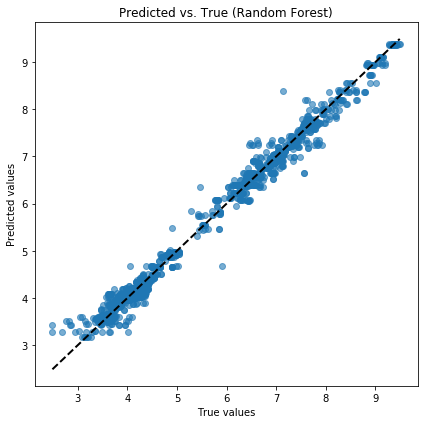

In [25]:
#want to see how model does when predicting over the entire dataset and visual the results, not really great practice but was curious
# Predict using the best estimator from grid search
y_pred = gs.best_estimator_.predict(X)

# Evaluate overall metrics on the full dataset
rmse_full = np.sqrt(mean_squared_error(y, y_pred))
mae_full  = mean_absolute_error(y, y_pred)
r2_full   = r2_score(y, y_pred)

print(f"Full dataset RMSE: {rmse_full:.4f}")
print(f"Full dataset MAE:  {mae_full:.4f}")
print(f"Full dataset R2:   {r2_full:.4f}")

plt.figure(figsize=(6,6))
plt.scatter(y, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)  # 1:1 line
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("Predicted vs. True (Random Forest)")
plt.tight_layout()
plt.show()

In [13]:
#this is all commented out becuase it doesn't show much and it uses the entire X set the model was trained on, so not great
# import geopandas as gpd
# from shapely.geometry import Point

# #want to map the actual and predicted DO
# df_compare = pd.DataFrame({
#     'lat':X[' lat'],
#     'lon':X[' lon'],
#     'DO_actual': np.ravel(y),
#     'DO_pred': y_pred
# })
# # Convert to GeoDataFrame
# geometry = [Point(xy) for xy in zip(df_compare["lon"], df_compare["lat"])]
# gdf = gpd.GeoDataFrame(df_compare, geometry=geometry, crs="EPSG:4326")  # WGS84

# fig, axes = plt.subplots(1, 2, figsize=(12,8), dpi=300)

# # Shared color limits
# vmin = min(gdf["DO_actual"].min(), gdf["DO_pred"].min())
# vmax = max(gdf["DO_actual"].max(), gdf["DO_pred"].max())

# # Actual DO
# gdf.plot(column="DO_actual", cmap="viridis", legend=False, ax=axes[0], markersize=40, vmin=vmin, vmax=vmax)
# axes[0].set_title("Actual DO")

# # Predicted DO
# gdf.plot(column="DO_pred", cmap="viridis", legend=False, ax=axes[1], markersize=40, vmin=vmin, vmax=vmax)
# axes[1].set_title("Predicted DO")

# # Add one shared colorbar
# sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=vmin, vmax=vmax))
# sm._A = []  # dummy array for colorbar
# cbar_ax = fig.add_axes([1, 0.15, 0.02, 0.7])  
# cbar = fig.colorbar(sm, cax=cbar_ax)
# cbar.set_label("DO")

# plt.tight_layout()
# plt.show()
#this doesn't actually show that much lol

In [ ]:
### Model 4: Gradient Boosting Regressor

In [26]:
# working GradientBoostingRegressor tuning pipeline (time-series CV)
import warnings
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import randint, uniform
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, GridSearchCV, cross_validate
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")

# reproducibility
RANDOM_STATE = 42

# time-series CV
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

# pipeline
pipe = Pipeline([
    # add preprocessing here if needed
    ('gb', GradientBoostingRegressor(random_state=RANDOM_STATE))
])

# randomized search space (use sensible ranges)
param_dist = {
    'gb__n_estimators': randint(100, 1000),
    'gb__max_depth': randint(2, 8),
    'gb__learning_rate': uniform(0.01, 0.29),   # 0.01 - 0.30
    'gb__min_samples_split': randint(2, 20),
    'gb__min_samples_leaf': randint(1, 20),
    'gb__subsample': uniform(0.6, 0.4),         # 0.6 - 1.0
    'gb__max_features': uniform(0.3, 0.7)       # 0.3 - 1.0 (as fraction)
}

rs = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=40,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2,
    random_state=RANDOM_STATE,
    refit=True
)

# run random search
rs.fit(X, y)
print("Random search best params:", rs.best_params_)
print("Random search best CV RMSE:", np.sqrt(-rs.best_score_))

# --- build a sane grid around numeric best values ---
best = rs.best_params_.copy()

def _make_linear_space(val, low_factor=0.7, high_factor=1.3, num=5, min_val=None, max_val=None):
    """Return a small linspace around val; if val is not float/int, return [val]."""
    try:
        v = float(val)
    except Exception:
        return [val]
    lo, hi = v * low_factor, v * high_factor
    if min_val is not None: lo = max(lo, min_val)
    if max_val is not None: hi = min(hi, max_val)
    if lo == hi:
        return [v]
    # integer-like parameters cast to int and unique
    if abs(v - round(v)) < 1e-6:
        arr = np.linspace(int(max(1, round(lo))), int(round(hi)), num, dtype=int)
        return sorted(set(arr.tolist()))
    return np.linspace(lo, hi, num).tolist()

# create grid using the keys used in the pipeline ('gb__...')
grid = {
    'gb__n_estimators': [best['gb__n_estimators'] - 50, best['gb__n_estimators'], best['gb__n_estimators'] + 50],
    'gb__learning_rate': [best['gb__learning_rate'] * f for f in [0.8, 1.0, 1.2]],
    'gb__max_depth': [best['gb__max_depth'] - 1, best['gb__max_depth'], best['gb__max_depth'] + 1],
}

# Grid search
gs = GridSearchCV(
    estimator=pipe,
    param_grid=grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    refit=True
)

gs.fit(X, y)
print("Grid-refined best params:", gs.best_params_)
print("Grid-refined best CV RMSE:", np.sqrt(-gs.best_score_))

# final evaluation using cross_validate to get per-fold stats
scoring = {
    'rmse': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred))),
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

cv_res = cross_validate(gs.best_estimator_, X, y, cv=tscv, scoring=scoring, return_train_score=True, n_jobs=-1)

def mean_std(key, sign_adjust=False):
    vals = cv_res[key]
    if sign_adjust:
        vals = -vals
    return vals.mean(), vals.std()

gb_rmse_mean, gb_rmse_std = mean_std('test_rmse')
gb_mae_mean, gb_mae_std   = mean_std('test_mae', sign_adjust=True)
gb_r2_mean, gb_r2_std     = mean_std('test_r2')

print(f"Final (CV) RMSE: {gb_rmse_mean:.4f} ± {gb_rmse_std:.4f}")
print(f"Final (CV) MAE:  {gb_mae_mean:.4f} ± {gb_mae_std:.4f}")
print(f"Final (CV) R2:   {gb_r2_mean:.4f} ± {gb_r2_std:.4f}")

# show training error if you care
train_rmse_mean, train_rmse_std = cv_res['train_rmse'].mean(), cv_res['train_rmse'].std()
print(f"Train RMSE (CV folds): {train_rmse_mean:.4f} ± {train_rmse_std:.4f}")

# feature importances from the fitted estimator (GridSearch refit)
final_gb = gs.best_estimator_.named_steps['gb']
if hasattr(final_gb, 'feature_importances_'):
    importances = final_gb.feature_importances_
    # show top 10 features (if X is array with unknown names)
    top_idx = np.argsort(importances)[::-1][:10]
    print("Top feature importances (idx: importance):")
    for i in top_idx:
        print(f"  {feature_names[i]}: {importances[i]:.6f}")
else:
    print("Final estimator doesn't expose feature_importances_.")


Fitting 5 folds for each of 40 candidates, totalling 200 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  52 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    9.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


Random search best params: {'gb__learning_rate': 0.07030308223177476, 'gb__max_depth': 5, 'gb__max_features': 0.42939811886786894, 'gb__min_samples_leaf': 18, 'gb__min_samples_split': 13, 'gb__n_estimators': 261, 'gb__subsample': 0.7580600944007257}
Random search best CV RMSE: 0.9450926770282027
Fitting 5 folds for each of 27 candidates, totalling 135 fits


[Parallel(n_jobs=-1)]: Done 120 out of 135 | elapsed:    3.8s remaining:    0.5s
[Parallel(n_jobs=-1)]: Done 135 out of 135 | elapsed:    4.2s finished


Grid-refined best params: {'gb__learning_rate': 0.0843636986781297, 'gb__max_depth': 4, 'gb__n_estimators': 261}
Grid-refined best CV RMSE: 1.1374229881964988
Final (CV) RMSE: 1.1071 ± 0.2607
Final (CV) MAE:  0.8623 ± 0.2376
Final (CV) R2:   -0.2023 ± 0.3056
Train RMSE (CV folds): 0.1455 ± 0.0240
Top feature importances (idx: importance):
   ssr: 0.787869
   t2m: 0.054262
  u10: 0.050918
   v10: 0.033045
   dayofyear: 0.023509
   modis_chlor: 0.017537
   ndvi: 0.016973
   modis_green: 0.004741
   red: 0.004517
   modis_blue: 0.003523


without lat, lon, year, month, dayofyear as features: the RMSE= 3.4492, MAE=2.7825, R2= -1.247

In [ ]:
### Model 5: MLP

In [28]:
# MLP tuning pipeline with fit-count cap (~2000 total fits)
import numpy as np
import warnings
from math import floor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, GridSearchCV, cross_validate
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.neural_network import MLPRegressor
from scipy.stats import randint, uniform

In [29]:
warnings.filterwarnings("ignore")
RANDOM_STATE = 42

# TimeSeries CV (change n_splits if you want)
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

# Upper cap on total fitted models (including CV folds)
MAX_TOTAL_FITS = 2000
# reserve some slots for the small grid refinement
GRID_COMBOS_TARGET = 30

# compute allowed number of parameter sets to evaluate (per-CV combo)
allowed_param_sets = max(10, floor(MAX_TOTAL_FITS / n_splits))
# allocate to random search first, leaving room for grid
n_iter_rs = max(10, allowed_param_sets - GRID_COMBOS_TARGET)
# but don't make n_iter too big (practical cap)
n_iter_rs = min(n_iter_rs, 800)

print(f"n_splits={n_splits}, allowed_param_sets={allowed_param_sets}, n_iter_random={n_iter_rs}, grid_targets≈{GRID_COMBOS_TARGET}")

# Pipeline (MLP needs scaling)
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(random_state=RANDOM_STATE, early_stopping=True, validation_fraction=0.1,
                         n_iter_no_change=10, tol=1e-4, max_iter=200))
])

# Randomized search space (sensible ranges for MLP)
# For hidden_layer_sizes we provide a sampled list of plausible architectures
hidden_choices = [
    (50,), (100,), (200,), (50, 25), (100, 50), (100, 100), (200, 100),
    (50, 50, 25), (100, 50, 25)
]

param_dist = {
    'mlp__hidden_layer_sizes': hidden_choices,
    'mlp__activation': ['relu', 'tanh'],           # 'identity' and 'logistic' are less common
    'mlp__solver': ['adam'],                       # use 'adam' (works well with early stopping)
    'mlp__alpha': uniform(1e-6, 1e-2),             # L2 penalty: 1e-6 .. 1e-2
    'mlp__learning_rate_init': uniform(1e-4, 5e-2),# 0.0001 .. 0.0501
    'mlp__batch_size': randint(32, 256),           # mini-batch sizes
    # you can also try learning_rate: 'constant' or 'adaptive'
    'mlp__learning_rate': ['constant', 'adaptive']
}

rs = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=n_iter_rs,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0,
    random_state=RANDOM_STATE,
    refit=True
)

# Run randomized search (coarse search)
rs.fit(X, y)
print("Random search best params:", rs.best_params_)
print("Random search best CV RMSE:", np.sqrt(-rs.best_score_))

# Build a small grid around the best random params (keep total combos small)
best = rs.best_params_.copy()

def _neighbor_layer_sizes(hls):
    """Generate a small set of nearby architectures around the chosen hidden_layer_sizes tuple."""
    if not isinstance(hls, tuple):
        try:
            hls = tuple(hls)
        except Exception:
            return [(50,)]
    res = set()
    base = list(hls)
    # keep original
    res.add(tuple(base))
    # increase/decrease neurons by ~20% (rounded)
    for i in range(len(base)):
        for factor in (0.8, 1.2):
            nb = base.copy()
            nb[i] = max(1, int(round(nb[i] * factor)))
            res.add(tuple(nb))
    # add/shrink depth by +/-1 layer (copy nearest size for new layer)
    if len(base) < 3:
        # add a smaller layer at end
        extra = max(1, int(round(base[-1] * 0.5)))
        res.add(tuple(base + [extra]))
    if len(base) > 1:
        # remove last layer
        res.add(tuple(base[:-1]))
    # some fixed alternatives
    res.update([(max(10, int(round(x*0.5))),) for x in base])
    return sorted(res)

# create small lists for grid (max combos ~ GRID_COMBOS_TARGET)
hls_grid = _neighbor_layer_sizes(best.get('mlp__hidden_layer_sizes', (100,)))
lr_grid = np.unique(np.clip(np.array([
    best.get('mlp__learning_rate_init', 0.001) * f for f in [0.5, 0.8, 1.0, 1.2, 1.5]
]), 1e-6, 1.0)).tolist()
alpha_grid = np.unique(np.clip(np.array([
    best.get('mlp__alpha', 1e-4) * f for f in [0.5, 1.0, 2.0, 5.0]
]), 1e-8, 1.0)).tolist()
batch_grid = sorted(set([
    best.get('mlp__batch_size', 64),
    max(16, int(best.get('mlp__batch_size', 64) // 2)),
    min(512, int(best.get('mlp__batch_size', 64) * 2))
]))

act_grid = [best.get('mlp__activation', 'relu')]
if act_grid[0] == 'relu':
    act_grid.append('tanh')
else:
    act_grid.append('relu')

lr_type_grid = [best.get('mlp__learning_rate', 'constant')]

# Build grid dict but keep it small — limit combinations
grid = {
    'mlp__hidden_layer_sizes': hls_grid[:6],  # cap number to keep combos small
    'mlp__learning_rate_init': lr_grid[:4],
    'mlp__alpha': alpha_grid[:4],
    'mlp__batch_size': batch_grid[:3],
    'mlp__activation': act_grid,
    'mlp__learning_rate': lr_type_grid
}

# estimate combos
from functools import reduce
from operator import mul
combo_counts = [len(v) for v in grid.values()]
total_combos = reduce(mul, combo_counts, 1)
print("Grid combos:", combo_counts, "=> total combos:", total_combos, "=> total fits (~):", total_combos * n_splits)

# If grid is still too big, trim some lists
MAX_GRID_COMBOS = max(1, GRID_COMBOS_TARGET)
if total_combos > MAX_GRID_COMBOS:
    # simple trim strategy: reduce each list to at most ceil(root_k) where root_k is kth-root
    import math
    target_per_param = int(math.ceil(MAX_GRID_COMBOS ** (1.0 / len(grid))))
    for k in list(grid.keys()):
        grid[k] = grid[k][:max(1, target_per_param)]
    combo_counts = [len(v) for v in grid.values()]
    total_combos = reduce(mul, combo_counts, 1)
    print("Trimmed grid combos:", combo_counts, "=> total combos now:", total_combos, "=> fits:", total_combos * n_splits)

# Grid search (small)
gs = GridSearchCV(
    estimator=pipe,
    param_grid=grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0,
    refit=True
)

gs.fit(X, y)
print("Grid-refined best params:", gs.best_params_)
print("Grid-refined best CV RMSE:", np.sqrt(-gs.best_score_))

# Final cross-validated metrics
scoring = {
    'rmse': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred))),
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

cv_res = cross_validate(gs.best_estimator_, X, y, cv=tscv, scoring=scoring, return_train_score=True, n_jobs=-1)

def mean_std(key, sign_adjust=False):
    vals = cv_res[key]
    if sign_adjust:
        vals = -vals
    return vals.mean(), vals.std()

mlp_rmse_mean, mlp_rmse_std = mean_std('test_rmse')
mlp_mae_mean, mlp_mae_std   = mean_std('test_mae', sign_adjust=True)
mlp_r2_mean, mlp_r2_std     = mean_std('test_r2')

print(f"Final (CV) RMSE: {mlp_rmse_mean:.4f} ± {mlp_rmse_std:.4f}")
print(f"Final (CV) MAE:  {mlp_mae_mean:.4f} ± {mlp_mae_std:.4f}")
print(f"Final (CV) R2:   {mlp_r2_mean:.4f} ± {mlp_r2_std:.4f}")

# final estimator
final_mlp = gs.best_estimator_.named_steps['mlp']
print("Final MLP iterations:", getattr(final_mlp, 'n_iter_', 'n_iter_ not available on this sklearn version'))

n_splits=5, allowed_param_sets=400, n_iter_random=370, grid_targets≈30
Random search best params: {'mlp__activation': 'tanh', 'mlp__alpha': 0.0005498261464647493, 'mlp__batch_size': 177, 'mlp__hidden_layer_sizes': (200, 100), 'mlp__learning_rate': 'constant', 'mlp__learning_rate_init': 0.03260836752216141, 'mlp__solver': 'adam'}
Random search best CV RMSE: 1.3423306822408223
Grid combos: [6, 4, 4, 3, 2, 1] => total combos: 576 => total fits (~): 2880
Trimmed grid combos: [2, 2, 2, 2, 2, 1] => total combos now: 32 => fits: 160
Grid-refined best params: {'mlp__activation': 'tanh', 'mlp__alpha': 0.00027491307323237465, 'mlp__batch_size': 177, 'mlp__hidden_layer_sizes': (50,), 'mlp__learning_rate': 'constant', 'mlp__learning_rate_init': 0.016304183761080705}
Grid-refined best CV RMSE: 1.7643590074525985
Final (CV) RMSE: 1.7450 ± 0.2607
Final (CV) MAE:  1.3736 ± 0.2440
Final (CV) R2:   -2.3264 ± 1.4960
Final MLP iterations: 112


without lat, lon, year, month, dayofyear as features: the RMSE= 4.1242, MAE=3.356, R2= -2.6061

### compare the different models

In [30]:
results = {
    "Random Forest": {"RMSE": rf_rmse_mean, "MAE": rf_mae_mean, "R2": rf_r2_mean},
    "Gradient Boosting": {"RMSE": gb_rmse_mean, "MAE": gb_mae_mean, "R2": gb_r2_mean},
    "MLP": {"RMSE": mlp_rmse_mean, "MAE": mlp_mae_mean, "R2": mlp_r2_mean},
    "SVR": {"RMSE": svr_rmse_mean, "MAE": svr_mae_mean, "R2": svr_r2_mean},
}
results

{'Random Forest': {'RMSE': 0.9124075226737858,
  'MAE': 0.6802101693934149,
  'R2': 0.18157574556260764},
 'Gradient Boosting': {'RMSE': 1.10714851594427,
  'MAE': 0.8622651098096318,
  'R2': -0.20234356406378268},
 'MLP': {'RMSE': 1.744990943119826,
  'MAE': 1.3736419414874432,
  'R2': -2.3264444056541973},
 'SVR': {'RMSE': 1.309459970037019,
  'MAE': 1.0235545004792692,
  'R2': -0.798884722270173}}

In [31]:
#want to see rf results to compare to target
y_pred_allX = final_rfr.predict(X)

In [32]:
print('prediction mean:',np.mean(y_pred_allX))
print('prediction min:',np.min(y_pred_allX))
print('prediction max:',np.max(y_pred_allX))
print('prediction median:',np.median(y_pred_allX))
print('prediction standard dev:',np.std(y_pred_allX))

prediction mean: 5.776116858997697
prediction min: 3.1759303721531005
prediction max: 9.385171129902478
prediction median: 6.349202520051609
prediction standard dev: 1.625203875393902


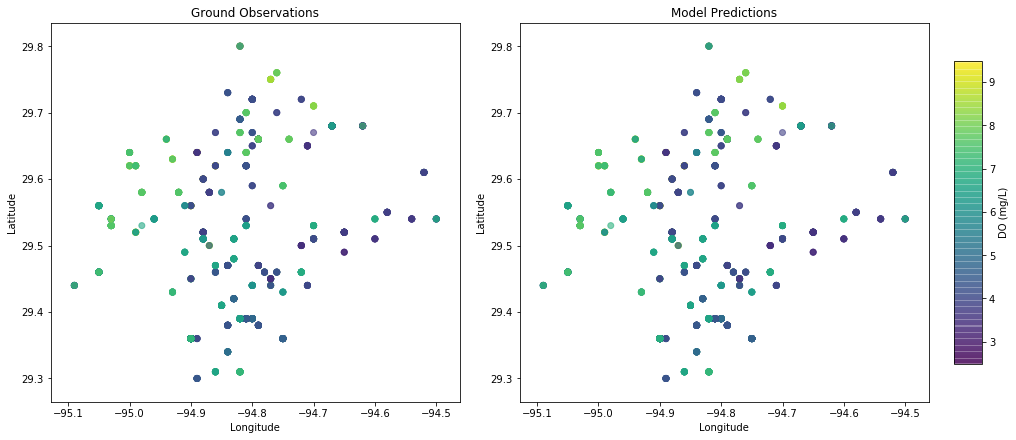

In [36]:
#shared color scale
vmin = min(y['ground_obs'].min(), y_pred_allX.min())
vmax = max(y['ground_obs'].max(), y_pred_allX.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 6),constrained_layout=True)

# Targets
sc1 = axes[0].scatter( X_og[' lon'], X_og[' lat'],c=y['ground_obs'],cmap='viridis',vmin=vmin, vmax=vmax,alpha=0.6)
axes[0].set_title("Ground Observations")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

# Predictions
sc2 = axes[1].scatter(X_og[' lon'], X_og[' lat'],c=y_pred_allX,cmap='viridis', vmin=vmin, vmax=vmax,alpha=0.6)
axes[1].set_title("Model Predictions")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

cbar = fig.colorbar(sc2, ax=axes, location='right', shrink=0.8, pad=0.02)
cbar.set_label("DO (mg/L)")

plt.show()


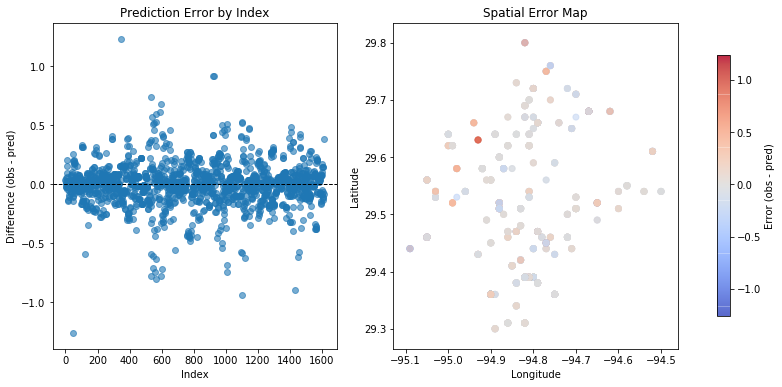

In [38]:
#want to plot the difference between actual and target
y_diff = y['ground_obs'] - y_pred_allX

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#error vs index
axes[0].scatter(range(len(y_diff)), y_diff, alpha=0.6)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1) 
axes[0].set_xlabel("Index")
axes[0].set_ylabel("Difference (obs - pred)")
axes[0].set_title("Prediction Error by Index")

# spatial error map
sc = axes[1].scatter(
    X_og[' lon'], X_og[' lat'],
    c=y_diff,
    cmap='coolwarm',
    alpha=0.6
)
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].set_title("Spatial Error Map")

cbar = fig.colorbar(sc, ax=axes, location='right', shrink=0.8)
cbar.set_label("Error (obs - pred)")

plt.show()


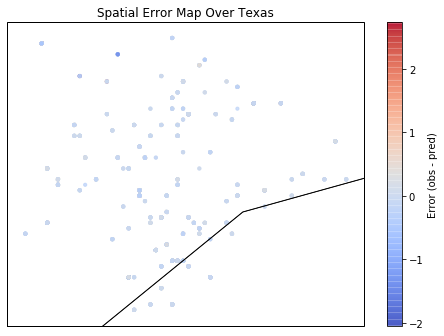

In [129]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add built‑in map features
ax.add_feature(cfeature.STATES, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)

# Scatter your points
sc = ax.scatter(
    X['lon'], X['lat'],
    c=y_diff,
    cmap='coolwarm',
    s=10,
    alpha=0.7,
    transform=ccrs.PlateCarree()
)

# Add colorbar
plt.colorbar(sc, ax=ax, shrink=0.7, label="Error (obs - pred)")

ax.set_title("Spatial Error Map Over Texas")
plt.show()

#### Just to test simple linear regression

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

tscv = TimeSeriesSplit(n_splits=5)
lin_reg = LinearRegression()

nmse_scores = -cross_val_score(
    lin_reg, X, y,
    scoring="neg_mean_squared_error",
    cv=tscv
)

rmse_scores = np.sqrt(nmse_scores)

print("Time-Series CV RMSE:", (rmse_scores))
print("Mean RMSE:", rmse_scores.mean())
print("Std RMSE:", rmse_scores.std())

Time-Series CV RMSE: [3.60596862 2.81005137 2.37973574 2.86409865 2.5153104 ]
Mean RMSE: 2.8350329557069736
Std RMSE: 0.4255182152211839


## Preparing Data for model prediction

In [20]:
#want a list of dates that were not used to train the models
X_og['date'] = pd.to_datetime(
    X_og[' year'].astype(int).astype(str) +
    X_og[' dayofyear'].astype(int).astype(str).str.zfill(3),
    format="%Y%j"
)

# Now the list of dates is:
X_dates = X_og['date'].drop_duplicates()
#X_dates

#### loading era5

In [21]:
#era5 data that was not used for model training
import rasterio
import xarray as xr
#era5 data
file = '/shared_space/Galveston_Bay/ERA5/ERA5-2018-2020_rescaled.nc'
ds = xr.open_dataset(file)
#want data that was not used to train model
ds_ERA = ds.valid_time.to_index()
unused_times = ds_ERA.difference(X_dates)
test_ERA = ds.sel(valid_time=unused_times)

#want daily timesteps
era5_daily_test = test_ERA.resample(valid_time="1D").mean()
era5_daily_test

/opt/conda/lib/python3.7/site-packages/xarray/core/nanops.py:160: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis=axis, dtype=dtype)


<xarray.Dataset>
Dimensions:     (latitude: 20, longitude: 20, valid_time: 1096)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 2018-01-01 2018-01-02 ... 2020-12-31
    number      int64 0
  * latitude    (latitude) float64 28.5 28.6 28.7 28.8 ... 30.1 30.2 30.3 30.4
  * longitude   (longitude) float64 -96.0 -95.9 -95.8 ... -94.3 -94.2 -94.1
Data variables:
    u10         (valid_time, latitude, longitude) float64 -3.278 -3.468 ... nan
    v10         (valid_time, latitude, longitude) float64 -9.402 -9.449 ... nan
    ssr         (valid_time, latitude, longitude) float64 3.128e+05 ... nan
    t2m         (valid_time, latitude, longitude) float64 280.1 280.1 ... nan
    wind_speed  (valid_time, latitude, longitude) float64 9.971 10.08 ... nan

#### loading modis

In [22]:
#modis data that was not used for training
#load and group the MODIS red, nir, and qc by date
import glob
from collections import defaultdict
import re
import datetime
from datetime import timedelta
os.chdir('/home/jovyan')

# define functions
# parse date from filename
def parse_date(file):
    # find the 'doyYYYYJJJ...' pattern (e.g. doy2019364000000 -> capture '2019364')
    m = re.search(r'doy(\d{7})', os.path.basename(file))
    if m:
        return m.group(1)
    
#convert key to timestamp
def string_to_timestamp(yyyydoy):
    year = int(yyyydoy[:4])
    doy  = int(yyyydoy[4:7])
    return pd.to_datetime(f"{year}-{doy}", format="%Y-%j")

files_500m_2020 = glob.glob('./shared_space/Galveston_Bay/MODIS_500/bands2020/*')
files_500m_2019 = glob.glob('./shared_space/Galveston_Bay/MODIS_500/*2019*')
files_500m_2018 = glob.glob('./shared_space/Galveston_Bay/MODIS_500/bands2018/*')

all_modis = files_500m_2020 + files_500m_2019 + files_500m_2018
all_files = sorted(all_modis)

# group files by datetime
groups = defaultdict(list)
for file in all_files:
    key = parse_date(file)
    #groups[key].append(file)
    if key is None:
        continue      # skip files without a valid date
    groups[key].append(file)
#check
print(len(groups))

1094


In [23]:
modis_dates = {key: string_to_timestamp(key) for key in groups.keys()}
#modis_dates

In [24]:
matched = {}

for key, ts in modis_dates.items():
    ts_np = np.datetime64(ts)

    try:
        era5_slice = era5_daily_test.sel(
            valid_time=ts_np,
            method="nearest",
            tolerance=np.timedelta64(12, "h")  # half-day window
        )
        matched[key] = era5_slice
    except KeyError:
        print(f"Warning: no ERA5 match within 12h for {key} ({ts_np})")



In [25]:
final = {}

for key in matched.keys():
    final[key] = {
        "date": modis_dates[key],
        "modis_files": groups[key],
        "era5": matched[key]
    }


In [26]:
final["2020001"]

{'date': Timestamp('2020-01-01 00:00:00'),
 'modis_files': ['./shared_space/Galveston_Bay/MODIS_500/bands2020/MYD09GA.061_QC_500m_1_doy2020001000000_aid0001.tif',
  './shared_space/Galveston_Bay/MODIS_500/bands2020/MYD09GA.061_sur_refl_b01_1_doy2020001000000_aid0001.tif',
  './shared_space/Galveston_Bay/MODIS_500/bands2020/MYD09GA.061_sur_refl_b02_1_doy2020001000000_aid0001.tif',
  './shared_space/Galveston_Bay/MODIS_500/bands2020/MYD09GA.061_sur_refl_b03_1_doy2020001000000_aid0001.tif',
  './shared_space/Galveston_Bay/MODIS_500/bands2020/MYD09GA.061_sur_refl_b04_1_doy2020001000000_aid0001.tif',
  './shared_space/Galveston_Bay/MODIS_500/bands2020/MYD09GA.061_sur_refl_b05_1_doy2020001000000_aid0001.tif',
  './shared_space/Galveston_Bay/MODIS_500/bands2020/MYD09GA.061_sur_refl_b06_1_doy2020001000000_aid0001.tif',
  './shared_space/Galveston_Bay/MODIS_500/bands2020/MYD09GA.061_sur_refl_b07_1_doy2020001000000_aid0001.tif'],
 'era5': <xarray.Dataset>
 Dimensions:     (latitude: 20, longitud

In [45]:

# scene_keys = selected_keys
# fp['modis_scene_idx'] = np.arange(len(selected_keys))

In [27]:
SCALE = 0.0001  # MODIS reflectance scale factor

def build_modis_era5_pixel_dataset(selected_keys, final):
    """
    Build a pixel-wise dataset for ML using MODIS + ERA5 for selected dates.
    
    Parameters
    ----------
    selected_keys : list of str
        MODIS DOY keys like ['2020001', '2020050', ...]
    final : dict
        Dictionary containing:
            final[key]["modis_files"] : list of MODIS band files
            final[key]["era5"]        : ERA5 daily slice (xarray Dataset)
            final[key]["date"]        : pandas Timestamp
    
    Returns
    -------
    df_all : pandas.DataFrame
        Pixel-wise dataset with MODIS + ERA5 features for all selected dates.
    """
    
    all_frames = []

    for key in selected_keys:
        print(f"Processing {key}...")

        # -----------------------------
        # 1. Get MODIS file list
        # -----------------------------
        flist = final[key]["modis_files"]
        date = final[key]["date"]

        # find band files
        red_fp   = next((f for f in flist if '_sur_refl_b01' in f.lower()), None)
        nir_fp   = next((f for f in flist if '_sur_refl_b02' in f.lower()), None)
        blue_fp  = next((f for f in flist if '_sur_refl_b03' in f.lower()), None)
        green_fp = next((f for f in flist if '_sur_refl_b04' in f.lower()), None)
        qc_fp    = next((f for f in flist if '_qc' in f.lower()), None)

        if not all([red_fp, nir_fp, blue_fp, green_fp, qc_fp]):
            print(f"Skipping {key}: incomplete MODIS scene")
            continue

        # -----------------------------
        # 2. Read MODIS grid + coordinates
        # -----------------------------
        with rasterio.open(red_fp) as src:
            height, width = src.height, src.width
            transform = src.transform

            rows, cols = np.meshgrid(
                np.arange(height), np.arange(width), indexing='ij'
            )
            xs, ys = rasterio.transform.xy(transform, rows, cols)
            modis_lons = np.array(xs)
            modis_lats = np.array(ys)

            red = src.read(1).astype(np.float32)

        with rasterio.open(nir_fp) as src:
            nir = src.read(1).astype(np.float32)

        with rasterio.open(blue_fp) as src:
            blue = src.read(1).astype(np.float32)

        with rasterio.open(green_fp) as src:
            green = src.read(1).astype(np.float32)

        with rasterio.open(qc_fp) as src:
            qc = src.read(1).astype(np.uint16)

        # -----------------------------
        # 3. QC mask + scaling
        # -----------------------------
        modland = qc & 0b11
        data_produced = ((qc >> 2) & 1) == 0
        aerosol_quality = (qc >> 4) & 0b1111
        good = (modland <= 2) & data_produced & (aerosol_quality <= 3)

        red   = np.where(good, red * SCALE, np.nan)
        nir   = np.where(good, nir * SCALE, np.nan)
        blue  = np.where(good, blue * SCALE, np.nan)
        green = np.where(good, green * SCALE, np.nan)

        # -----------------------------
        # 4. MODIS indices
        # -----------------------------
        ndvi = (red - nir) / (red + nir)
        chlor = blue / green

        # -----------------------------
        # 5. ERA5 → interpolate to MODIS grid
        # -----------------------------
        era5_day = final[key]["era5"]

        era5_interp = era5_day.interp(
            latitude=(("y", "x"), modis_lats),
            longitude=(("y", "x"), modis_lons),
            method="nearest"
        )

        ws  = era5_interp["wind_speed"].values
        ssr = era5_interp["ssr"].values
        t2m = era5_interp["t2m"].values
        u10 = era5_interp["u10"].values
        v10 = era5_interp["v10"].values

        # -----------------------------
        # 6. Build DataFrame for this day
        # -----------------------------
        df = pd.DataFrame({
            "lat": modis_lats.ravel(),
            "lon": modis_lons.ravel(),
            "red": red.ravel(),
            "nir": nir.ravel(),
            "ndvi": ndvi.ravel(),
            "modis_blue": blue.ravel(),
            "modis_green": green.ravel(),
            "modis_chlor": chlor.ravel(),
            "wind_speed": ws.ravel(),
            "u10": u10.ravel(),
            "v10": v10.ravel(),
            "ssr": ssr.ravel(),
            "t2m": t2m.ravel(),
            "month": date.month,
            "dayofyear": date.dayofyear,
            "date": date
        })

        all_frames.append(df)

    # -----------------------------
    # 7. Combine all days
    # -----------------------------
    df_all = pd.concat(all_frames, ignore_index=True)
    return df_all


## Now can test a day!

In [28]:
#check if day was used to train
(X_og['date'] == '2020-01-10').any()

False

In [274]:
#getting feature data for Jan 10th 2020!
selected_keys = ['2020004']
testday = build_modis_era5_pixel_dataset(selected_keys, final)
both_nan = (
    testday['red'].isna() &
    testday['wind_speed'].isna()
).sum()

both_nan

Processing 2020004...


6554

In [229]:
#testday.describe()

In [275]:
df_jan = testday.dropna()
X.columns = X.columns.str.strip()
df_jan102020_clean = df_jan.drop(columns=['date'])
# Enforce identical order
df_jan_clean = df_jan102020_clean[X.columns]

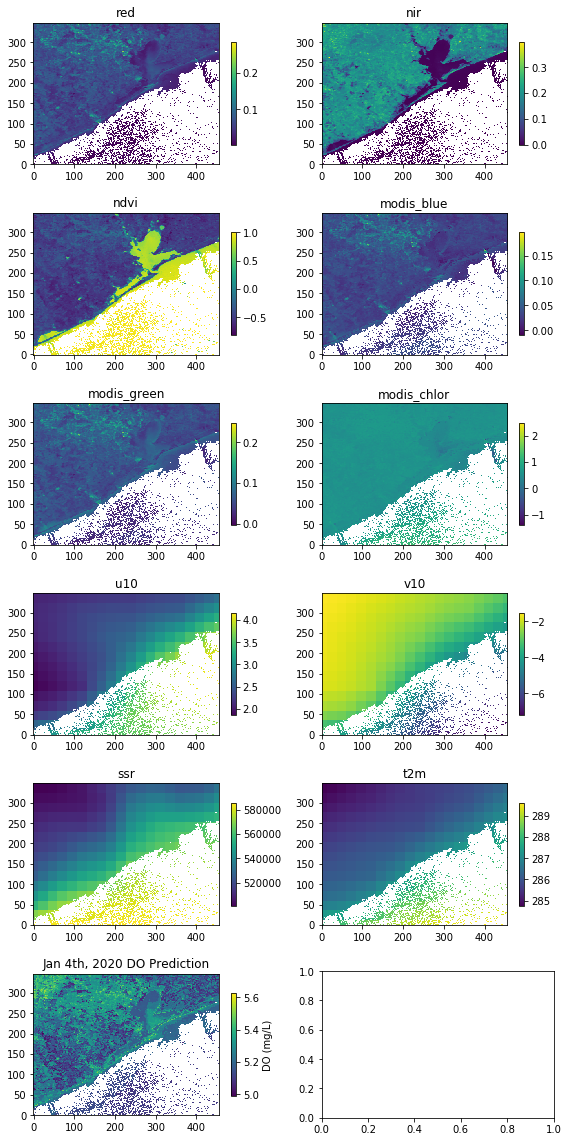

In [368]:
#want to explore inputs and prediction
H = df_jan['lat'].nunique()
W = df_jan['lon'].nunique()

f_plot = ['red', 'nir', 'ndvi', 'modis_blue', 'modis_green','modis_chlor', 'u10','v10', 'ssr', 't2m']

n = len(f_plot)
cols = 2
rows = int(np.ceil((n+1) / cols))

#for reshaping
df_jan_clean_with_coords = df_jan_clean.copy()
df_jan_clean_with_coords['lat'] = df_jan['lat'].values
df_jan_clean_with_coords['lon'] = df_jan['lon'].values

fig, axes = plt.subplots(rows, cols, figsize=(8, 16))
axes = axes.flatten()

for i, f in enumerate(f_plot):
    # reshape each feature into H×W grid
    #grid = df_sep6_clean[f].values.reshape(H, W)
    grid = df_jan_clean_with_coords.pivot(index='lat', columns='lon', values=f).values
    im = axes[i].imshow(grid, cmap='viridis', origin='lower')
    axes[i].set_title(f)
    fig.colorbar(im, ax=axes[i], shrink=0.7)

#try predict with the grid of jan 10 2020 data
y_pred_jan = final_rfr.predict(df_jan_clean)
df_jan_clean_with_coords['pred_DO'] = y_pred_jan
pred_grid_jan = df_jan_clean_with_coords.pivot(
    index='lat', columns='lon', values='pred_DO').values
#y_pred_grid = y_pred.reshape(H, W)

im_pred = axes[n].imshow(pred_grid_jan, cmap='viridis', origin='lower')
axes[n].set_title("Jan 4th, 2020 DO Prediction")
fig.colorbar(im_pred, ax=axes[n], shrink=0.7, label='DO (mg/L)')

plt.tight_layout()
plt.show()

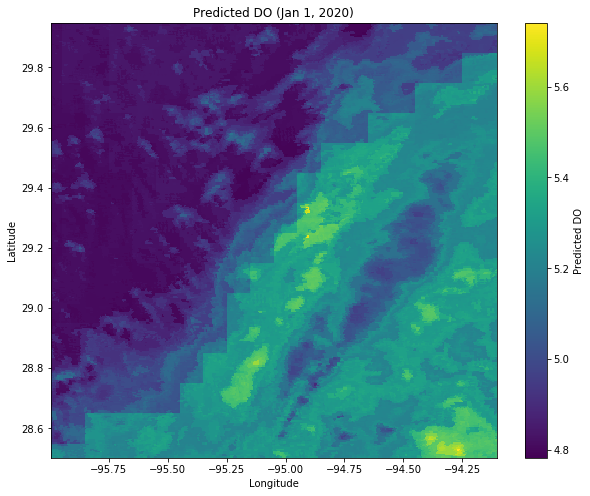

In [35]:
#just looking at prediction in big plot

lat_grid = df_jan102020['lat'].values.reshape(H, W)
lon_grid = df_jan102020['lon'].values.reshape(H, W)

plt.figure(figsize=(10, 8))
plt.pcolormesh(lon_grid, lat_grid, y_pred_grid, cmap='viridis', shading='auto')
plt.colorbar(label='Predicted DO')
plt.title('Predicted DO (Jan 1, 2020)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
#plt.gca().invert_yaxis()
plt.show()


In [370]:
#just looking at the locations that match the locations of the target
# Copy the dataframes
df1 = df_jan.copy()       
df2 = X_og.copy()       

# Round coordinates for matching
df1['lat_r'] = df1['lat'].round(2)
df1['lon_r'] = df1['lon'].round(2)

df2['lat_r'] = df2[' lat'].round(2)
df2['lon_r'] = df2[' lon'].round(2)

#Build mask of matching locations
mask = df1.set_index(['lat_r', 'lon_r']).index.isin(
        df2.set_index(['lat_r', 'lon_r']).index)

# Extract the matching lat/lon rows
jan_locs = df1[mask].copy()

# Keep the rounded coordinates as the final lat/lon
jan_locs['lat'] = jan_locs['lat_r']
jan_locs['lon'] = jan_locs['lon_r']

# Step 5: Apply the SAME mask to the clean dataframe
# (df_jan102020_clean has no lat/lon and is in correct feature order)
jan_clean_for_pred = df_jan102020_clean.loc[mask].copy()

# Step 6: Predict using the clean dataframe
y_pred_jan_tl = final_rfr.predict(jan_clean_for_pred)

# Step 7: Attach predictions back to the lat/lon dataframe
jan_locs['pred_DO'] = y_pred_jan_tl


ValueError: Number of features of the model must match the input. Model n_features is 11 and input n_features is 15 

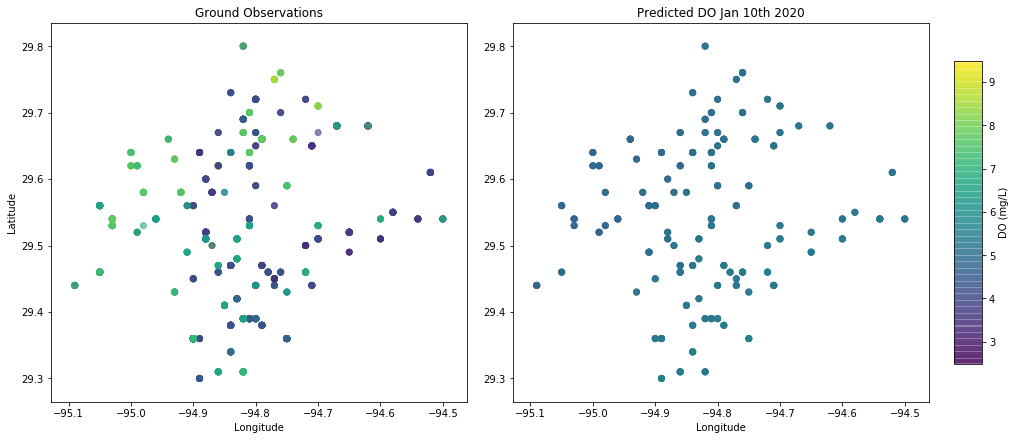

In [39]:
#plotting the target locations and the predictions at the same spot
vmin = min(y['ground_obs'].min(), y_pred_jan_tl.min())
vmax = max(y['ground_obs'].max(), y_pred_jan_tl.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

#Ground Observations
sc1 = axes[0].scatter(
    X_og[' lon'], X_og[' lat'],
    c=y['ground_obs'],
    cmap='viridis',
    vmin=vmin, vmax=vmax,
    alpha=0.6)
axes[0].set_title("Ground Observations")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

#Predictions at matched Jan 10 locations
sc2 = axes[1].scatter(
    jan_locs['lon'], jan_locs['lat'],
    c=y_pred_jan_tl,
    cmap='viridis',
    vmin=vmin, vmax=vmax,
    alpha=0.6)
axes[1].set_title("Predicted DO Jan 10th 2020")
axes[1].set_xlabel("Longitude")

# shared colorbar
cbar = fig.colorbar(sc2, ax=axes, location='right', shrink=0.8, pad=0.02)
cbar.set_label("DO (mg/L)")

plt.show()


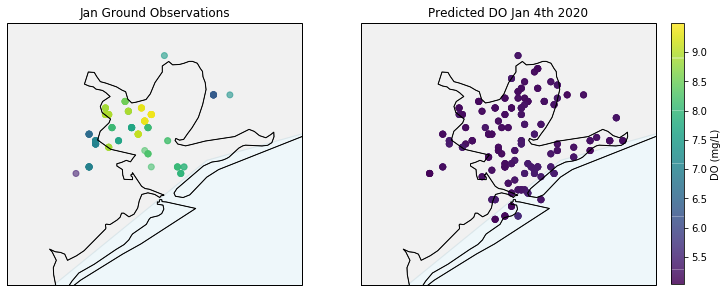

In [371]:
#just looking at the locations that match the locations of the target
# Copy the dataframes
df1 = df_jan.copy()       
df2 = X_og.copy()       

# Round coordinates for matching
df1['lat_r'] = df1['lat'].round(2)
df1['lon_r'] = df1['lon'].round(2)

df2['lat_r'] = df2[' lat'].round(2)
df2['lon_r'] = df2[' lon'].round(2)

#Build mask of matching locations
mask = df1.set_index(['lat_r', 'lon_r']).index.isin(
        df2.set_index(['lat_r', 'lon_r']).index)

# Extract the matching lat/lon rows
jan_locs = df1[mask].copy()

# Keep the rounded coordinates as the final lat/lon
jan_locs['lat'] = jan_locs['lat_r']
jan_locs['lon'] = jan_locs['lon_r']

# Step 5: Apply the SAME mask to the clean dataframe
# df_may29_clean has no lat/lon and is in correct feature order)
jan_clean_for_pred = df_jan_clean.loc[mask].copy()

# Step 6: Predict using the clean dataframe
y_pred_jan_tl = final_rfr.predict(jan_clean_for_pred)

# Step 7: Attach predictions back to the lat/lon dataframe
jan_locs['pred_DO'] = y_pred_jan_tl

#comapring just the points in the same month
idx_jan = X_og[X_og[' month'] == 1].index
x_jan = X_og[X_og[' month'] == 1]
y_jan = y.loc[idx_jan]
y_jan.describe()

vmin = min(y_jan['ground_obs'].min(), y_pred_jan_tl.min())
vmax = max(y_jan['ground_obs'].max(), y_pred_jan_tl.max())



# Create Cartopy subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                         subplot_kw={'projection': ccrs.PlateCarree()})

# Add geographic features to both axes
for ax in axes:
    ax.coastlines(resolution='10m')
    ax.add_feature(cfeature.STATES.with_scale('10m'), linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2)
    ax.set_extent([-95.3, -94.4, 29.1, 29.9], crs=ccrs.PlateCarree())  # zoom to Galveston Bay

#Ground Observations
sc1 = axes[0].scatter(
    x_jan[' lon'], x_jan[' lat'],
    c=y_jan['ground_obs'],
    cmap='viridis',
    vmin=vmin, vmax=vmax,
    alpha=0.6)
axes[0].set_title("Jan Ground Observations")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

#Predictions at matched may 29 locations
sc2 = axes[1].scatter(
    jan_locs['lon'], jan_locs['lat'],
    c=y_pred_jan_tl,
    cmap='viridis',
    vmin=vmin, vmax=vmax,
    alpha=0.6)
axes[1].set_title("Predicted DO Jan 4th 2020")
axes[1].set_xlabel("Longitude")

# shared colorbar
cbar = fig.colorbar(sc2, ax=axes, location='right', shrink=0.8, pad=0.02)
cbar.set_label("DO (mg/L)")

plt.show()

In [63]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# Data you already have
# x_jan: DataFrame with ' lon', ' lat' and y_jan['ground_obs']
# jan_locs: DataFrame with 'lon','lat'
# y_pred_jan_tl: array-like predicted DO aligned with jan_locs

# color scale bounds (use same as in your Matplotlib version)
vmin = min(y_jan['ground_obs'].min(), np.min(y_pred_jan_tl))
vmax = max(y_jan['ground_obs'].max(), np.max(y_pred_jan_tl))

# bounding box (same extent you used)
extent = [-95.1, -94.45, 29.29, 29.8]
lons_box = [extent[0], extent[1], extent[1], extent[0], extent[0]]
lats_box = [extent[2], extent[2], extent[3], extent[3], extent[2]]

# center
center_lon = (extent[0] + extent[1]) / 2
center_lat = (extent[2] + extent[3]) / 2

# create two mapbox subplots
fig = make_subplots(rows=1, cols=2,
                    specs=[[{"type": "mapbox"}, {"type": "mapbox"}]],
                    subplot_titles=("Jan Ground Observations", "Predicted DO Jan 10th 2020"))

# Shared colorscale
colorscale = "Viridis"

# Left: ground observations (colorbar shown here)
fig.add_trace(
    go.Scattermapbox(
        lon=x_jan[' lon'],
        lat=x_jan[' lat'],
        mode='markers',
        marker=go.scattermapbox.Marker(
            size=8,
            color=y_jan['ground_obs'],
            colorscale=colorscale,
            cmin=vmin, cmax=vmax,
            opacity=0.8,
            colorbar=dict(
                title="DO (mg/L)",
                thickness=10,     # bar width in px
                len=0.7,          # fraction of plot height
                yanchor="middle",
                y=0.5
            )
        ),
        hovertemplate="DO: %{marker.color:.2f}<br>Lon: %{lon:.4f}<br>Lat: %{lat:.4f}<extra></extra>",
        showlegend=False
    ),
    row=1, col=1
)

# Left: bounding box polygon (line)
fig.add_trace(
    go.Scattermapbox(
        lon=lons_box,
        lat=lats_box,
        mode='lines',
        line=dict(width=2, color='black'),
        showlegend=False,
        hoverinfo='none'
    ),
    row=1, col=1
)

# Right: predictions (no colorbar, same cmin/cmax & colorscale)
fig.add_trace(
    go.Scattermapbox(
        lon=jan_locs['lon'],
        lat=jan_locs['lat'],
        mode='markers',
        marker=go.scattermapbox.Marker(
            size=8,
            color=y_pred_jan_tl,
            colorscale=colorscale,
            cmin=vmin, cmax=vmax,
            opacity=0.8,
        ),
        hovertemplate="Pred DO: %{marker.color:.2f}<br>Lon: %{lon:.4f}<br>Lat: %{lat:.4f}<extra></extra>",
        showlegend=False
    ),
    row=1, col=2
)

# Right: bounding box polygon
fig.add_trace(
    go.Scattermapbox(
        lon=lons_box,
        lat=lats_box,
        mode='lines',
        line=dict(width=2, color='black'),
        showlegend=False,
        hoverinfo='none'
    ),
    row=1, col=2
)

# update mapbox layout for each subplot
mapbox_style = "open-street-map"   # doesn't require a token
fig.update_layout(
    mapbox1=dict(
        style=mapbox_style,
        center=dict(lat=center_lat, lon=center_lon),
        zoom=10,
        domain=dict(x=[0.0, 0.48], y=[0, 1])  # left subplot domain (optional fine control)
    ),
    mapbox2=dict(
        style=mapbox_style,
        center=dict(lat=center_lat, lon=center_lon),
        zoom=10,
        domain=dict(x=[0.52, 1.0], y=[0, 1])  # right subplot domain
    ),
    margin=dict(l=30, r=30, t=40, b=10),
    height=500,
    width=1000,
    title_text="Jan Observations and Predictions (shared color scale)"
)

# ensure the first trace uses mapbox1 and second mapbox2, etc.
# Plotly auto-assigns mapbox traces to mapbox1, mapbox2 in subplot order.

fig.show()


### Going to make all the same maps but for a day in summer!

In [316]:
#check if day was used to train
(X_og['date'] == '2020-05-19').any()

False

In [312]:
#getting feature data for Jan 10th 2020!
selected_keys = ['2020140']
testday = build_modis_era5_pixel_dataset(selected_keys, final)

#checks how many NA values there are perfer <1000
both_nan = (
    testday['red'].isna() &
    testday['wind_speed'].isna()
).sum()

both_nan

Processing 2020140...


3576

In [313]:
#drop na values
df_may29 = testday.dropna()

In [314]:
#want the features to appear in the same order as the training dataset
X.columns = X.columns.str.strip()
df_may29_clean = df_may29.drop(columns=['date'])
# Enforce identical order
df_may29_clean = df_may29_clean[X.columns]

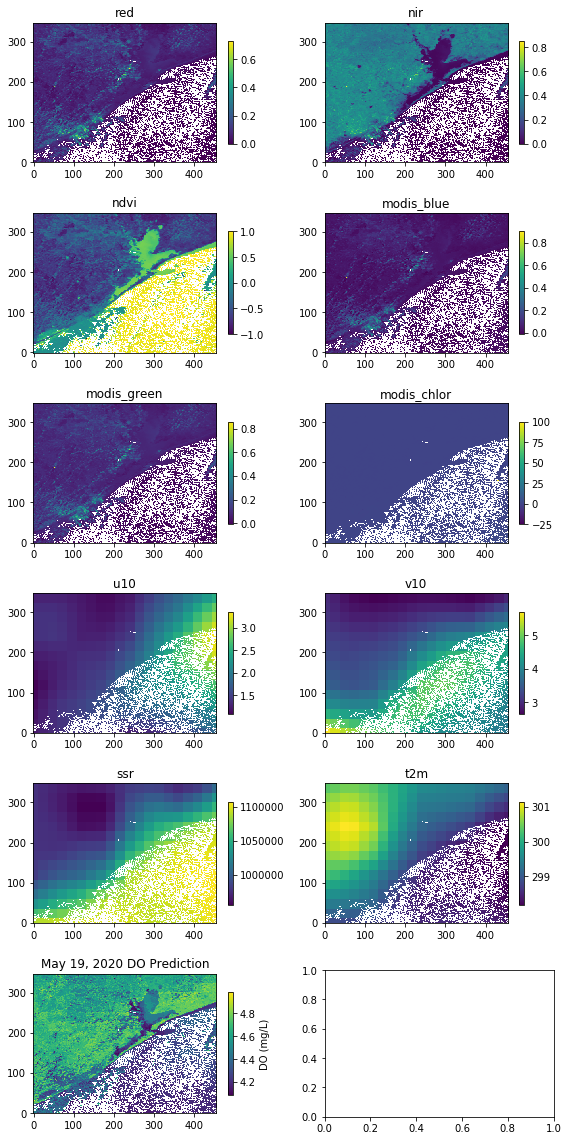

In [351]:
#want to explore inputs and prediction
H = df_may29['lat'].nunique()
W = df_may29['lon'].nunique()

f_plot = ['red', 'nir', 'ndvi', 'modis_blue', 'modis_green','modis_chlor', 'u10','v10', 'ssr', 't2m']

n = len(f_plot)
cols = 2
rows = int(np.ceil((n+1) / cols))

#for reshaping
df_may_clean_with_coords = df_may29_clean.copy()
df_may_clean_with_coords['lat'] = df_may29['lat'].values
df_may_clean_with_coords['lon'] = df_may29['lon'].values

fig, axes = plt.subplots(rows, cols, figsize=(8, 16))
axes = axes.flatten()

for i, f in enumerate(f_plot):
    # reshape each feature into H×W grid
    #grid = df_sep6_clean[f].values.reshape(H, W)
    grid = df_may_clean_with_coords.pivot(index='lat', columns='lon', values=f).values
    im = axes[i].imshow(grid, cmap='viridis', origin='lower')
    axes[i].set_title(f)
    fig.colorbar(im, ax=axes[i], shrink=0.7)

#try predict with the grid of jan 10 2020 data
y_pred_may = final_rfr.predict(df_may29_clean)
df_may_clean_with_coords['pred_DO'] = y_pred_may
pred_grid_may = df_may_clean_with_coords.pivot(
    index='lat', columns='lon', values='pred_DO').values
#y_pred_grid = y_pred.reshape(H, W)

im_pred = axes[n].imshow(pred_grid_may, cmap='viridis', origin='lower')
axes[n].set_title("May 19, 2020 DO Prediction")
fig.colorbar(im_pred, ax=axes[n], shrink=0.7, label='DO (mg/L)')

plt.tight_layout()
plt.show()

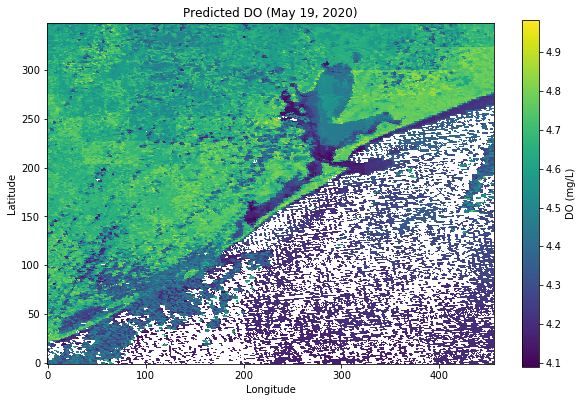

In [320]:
#just looking at prediction in big plot
#just looking at prediction in big plot

lat_grid = df_may_clean_with_coords.pivot(index='lat', columns='lon', values='lat').values
lon_grid = df_may_clean_with_coords.pivot(index='lat', columns='lon', values='lon').values

plt.figure(figsize=(10, 8))
plt.imshow(pred_grid, cmap='viridis', origin='lower')
plt.title('Predicted DO (May 19, 2020)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(label = 'DO (mg/L)', shrink= 0.8)
#plt.gca().invert_yaxis()
plt.show()


In [365]:
#just looking at the locations that match the locations of the target
# Copy the dataframes
df1 = df_may29.copy()       
df2 = X_og.copy()       

# Round coordinates for matching
df1['lat_r'] = df1['lat'].round(2)
df1['lon_r'] = df1['lon'].round(2)

df2['lat_r'] = df2[' lat'].round(2)
df2['lon_r'] = df2[' lon'].round(2)

#Build mask of matching locations
mask = df1.set_index(['lat_r', 'lon_r']).index.isin(
        df2.set_index(['lat_r', 'lon_r']).index)

# Extract the matching lat/lon rows
may_locs = df1[mask].copy()

# Keep the rounded coordinates as the final lat/lon
may_locs['lat'] = may_locs['lat_r']
may_locs['lon'] = may_locs['lon_r']

# Step 5: Apply the SAME mask to the clean dataframe
# df_may29_clean has no lat/lon and is in correct feature order)
may_clean_for_pred = df_may29_clean.loc[mask].copy()

# Step 6: Predict using the clean dataframe
y_pred_may_tl = final_rfr.predict(may_clean_for_pred)

# Step 7: Attach predictions back to the lat/lon dataframe
may_locs['pred_DO'] = y_pred_may_tl

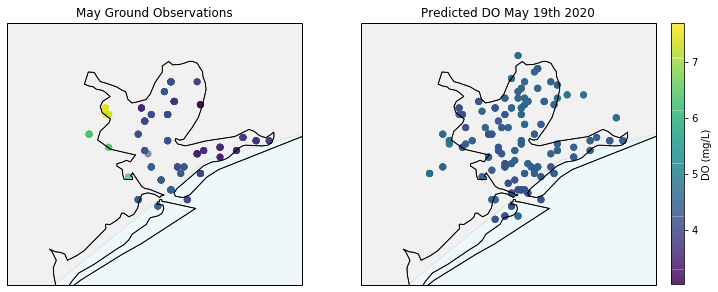

In [367]:
#comapring just the points in the same month
idx_may = X_og[X_og[' month'] == 5].index
x_may = X_og[X_og[' month'] == 5]
y_may = y.loc[idx_may]
y_may.describe()

vmin = min(y_may['ground_obs'].min(), y_pred_may_tl.min())
vmax = max(y_may['ground_obs'].max(), y_pred_may_tl.max())



# Create Cartopy subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                         subplot_kw={'projection': ccrs.PlateCarree()})

# Add geographic features to both axes
for ax in axes:
    ax.coastlines(resolution='10m')
    ax.add_feature(cfeature.STATES.with_scale('10m'), linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2)
    ax.set_extent([-95.3, -94.4, 29.1, 29.9], crs=ccrs.PlateCarree())  # zoom to Galveston Bay

#Ground Observations
sc1 = axes[0].scatter(
    x_may[' lon'], x_may[' lat'],
    c=y_may['ground_obs'],
    cmap='viridis',
    vmin=vmin, vmax=vmax,
    alpha=0.6)
axes[0].set_title("May Ground Observations")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

#Predictions at matched may 29 locations
sc2 = axes[1].scatter(
    may_locs['lon'], may_locs['lat'],
    c=y_pred_may_tl,
    cmap='viridis',
    vmin=vmin, vmax=vmax,
    alpha=0.6)
axes[1].set_title("Predicted DO May 19th 2020")
axes[1].set_xlabel("Longitude")

# shared colorbar
cbar = fig.colorbar(sc2, ax=axes, location='right', shrink=0.8, pad=0.02)
cbar.set_label("DO (mg/L)")

plt.show()

### Another day in the warm part of the year?

In [122]:
#check if day was used to train
(X_og['date'] == '2020-08-29').any()

False

In [197]:
#getting feature data for day 2020!
selected_keys = ['2020231']  #250 has 965  #237 has 1005  #242 has 924
testday = build_modis_era5_pixel_dataset(selected_keys, final)

#checks how many NA values there are perfer <1000
both_nan = (
    testday['red'].isna() &
    testday['wind_speed'].isna()
).sum()

both_nan

Processing 2020231...


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:89: RuntimeWarning:

invalid value encountered in true_divide



4451

In [198]:
#drop na values
df_aug29 = testday.dropna()

#want the features to appear in the same order as the training dataset
X.columns = X.columns.str.strip()
df_aug29_clean = df_aug29.drop(columns=['date'])
# Enforce identical order
df_aug29_clean = df_aug29_clean[X.columns]

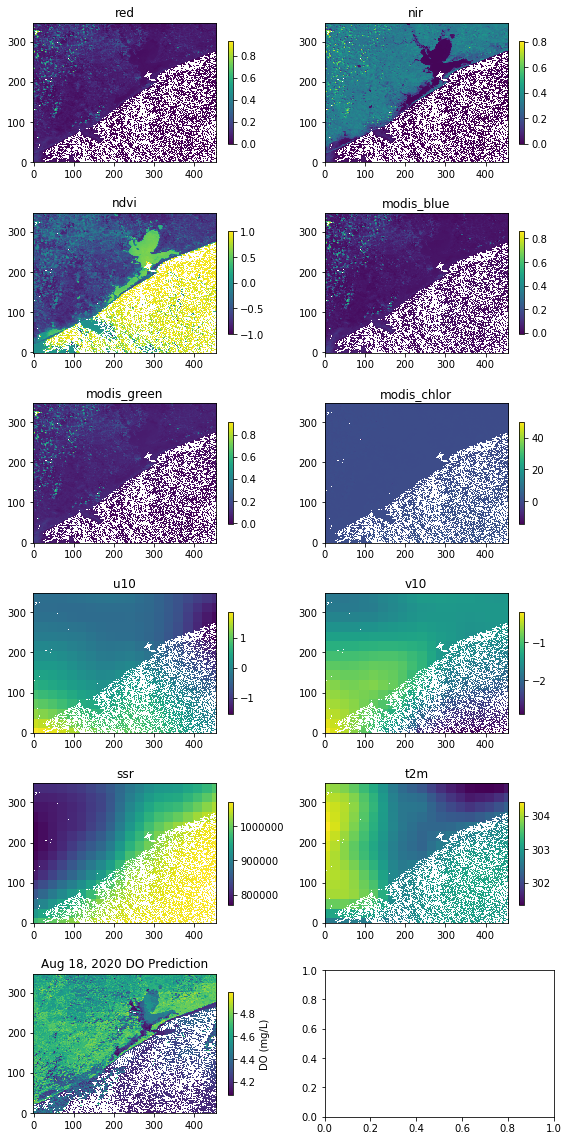

In [350]:
#want to explore inputs and prediction
H = df_aug29['lat'].nunique()
W = df_aug29['lon'].nunique()

f_plot = ['red', 'nir', 'ndvi', 'modis_blue', 'modis_green','modis_chlor', 'u10','v10', 'ssr', 't2m']

n = len(f_plot)
cols = 2
rows = int(np.ceil((n+1) / cols))

#for reshaping
df_aug29_clean_with_coords = df_aug29_clean.copy()
df_aug29_clean_with_coords['lat'] = df_aug29['lat'].values
df_aug29_clean_with_coords['lon'] = df_aug29['lon'].values

fig, axes = plt.subplots(rows, cols, figsize=(8, 16))
axes = axes.flatten()

for i, f in enumerate(f_plot):
    # reshape each feature into H×W grid
    #grid = df_sep6_clean[f].values.reshape(H, W)
    grid = df_aug29_clean_with_coords.pivot(index='lat', columns='lon', values=f).values
    im = axes[i].imshow(grid, cmap='viridis', origin='lower')
    axes[i].set_title(f)
    fig.colorbar(im, ax=axes[i], shrink=0.7)

#try predict with the grid of jan 10 2020 data
y_pred_aug = final_rfr.predict(df_aug29_clean)
df_aug29_clean_with_coords['pred_DO'] = y_pred_aug
pred_grid_aug = df_aug29_clean_with_coords.pivot(
    index='lat', columns='lon', values='pred_DO').values
#y_pred_grid = y_pred.reshape(H, W)

im_pred = axes[n].imshow(pred_grid, cmap='viridis', origin='lower')
axes[n].set_title("Aug 18, 2020 DO Prediction")
fig.colorbar(im_pred, ax=axes[n], shrink=0.7, label='DO (mg/L)')

plt.tight_layout()
plt.show()

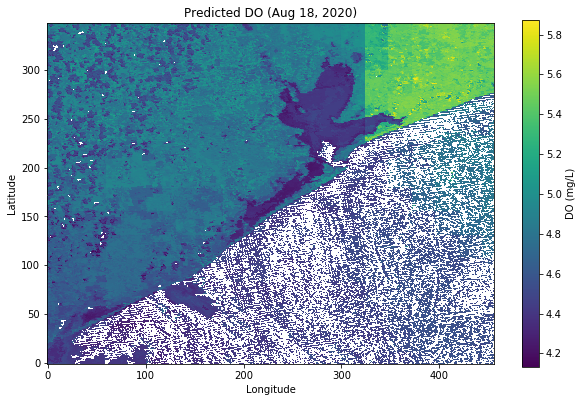

In [200]:
#just looking at prediction in big plot

lat_grid = df_aug29_clean_with_coords.pivot(index='lat', columns='lon', values='lat').values
lon_grid = df_aug29_clean_with_coords.pivot(index='lat', columns='lon', values='lon').values

plt.figure(figsize=(10, 8))
plt.imshow(pred_grid, cmap='viridis', origin='lower')
plt.title('Predicted DO (Aug 18, 2020)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(label = 'DO (mg/L)', shrink= 0.8)
#plt.gca().invert_yaxis()
plt.show()

In [241]:
#just looking at the locations that match the locations of the target
# Copy the dataframes
df1 = df_aug29.copy()       
df2 = X_og.copy()       

# Round coordinates for matching
df1['lat_r'] = df1['lat'].round(2)
df1['lon_r'] = df1['lon'].round(2)

df2['lat_r'] = df2[' lat'].round(2)
df2['lon_r'] = df2[' lon'].round(2)

#Build mask of matching locations
mask = df1.set_index(['lat_r', 'lon_r']).index.isin(
        df2.set_index(['lat_r', 'lon_r']).index)

# Extract the matching lat/lon rows
aug_locs = df1[mask].copy()

# Keep the rounded coordinates as the final lat/lon
aug_locs['lat'] = aug_locs['lat_r']
aug_locs['lon'] = aug_locs['lon_r']

# Step 5: Apply the SAME mask to the clean dataframe
# df_may29_clean has no lat/lon and is in correct feature order)
aug_clean_for_pred = df_aug29_clean.loc[mask].copy()

# Step 6: Predict using the clean dataframe
y_pred_aug_tl = final_rfr.predict(aug_clean_for_pred)

# Step 7: Attach predictions back to the lat/lon dataframe
aug_locs['pred_DO'] = y_pred_aug_tl

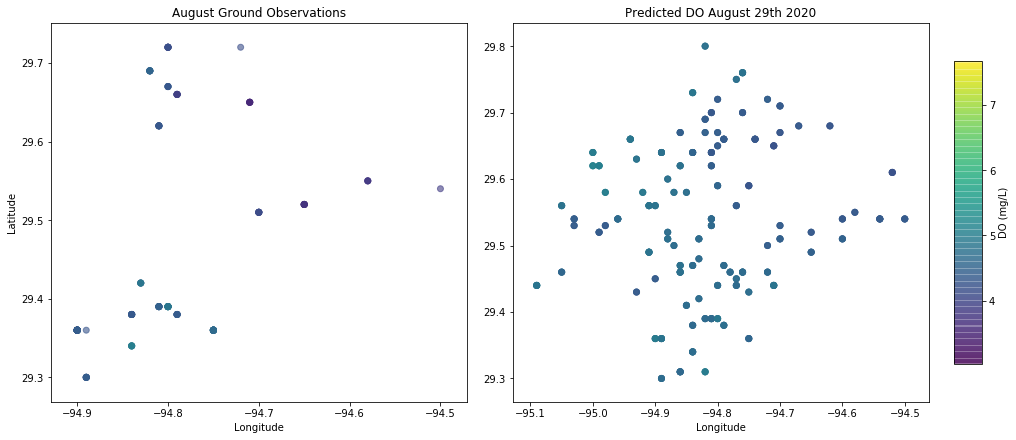

In [244]:
#comapring just the points in the same month
idx_aug = X_og[X_og[' month'] == 8].index
x_aug = X_og[X_og[' month'] == 8]
y_aug = y.loc[idx_aug]
y_aug.describe()

vmin = min(y_may['ground_obs'].min(), y_pred.min())
vmax = max(y_may['ground_obs'].max(), y_pred.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

#Ground Observations
sc1 = axes[0].scatter(
    x_aug[' lon'], x_aug[' lat'],
    c=y_aug['ground_obs'],
    cmap='viridis',
    vmin=vmin, vmax=vmax,
    alpha=0.6)
axes[0].set_title("August Ground Observations")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

#Predictions at matched may 29 locations
sc2 = axes[1].scatter(
    aug_locs['lon'], aug_locs['lat'],
    c=y_pred_aug_tl,
    cmap='viridis',
    vmin=vmin, vmax=vmax,
    alpha=0.6)
axes[1].set_title("Predicted DO August 29th 2020")
axes[1].set_xlabel("Longitude")

# shared colorbar
cbar = fig.colorbar(sc2, ax=axes, location='right', shrink=0.8, pad=0.02)
cbar.set_label("DO (mg/L)")

plt.show()

### Another Day!

In [169]:
#check if day was used to train
(X_og['date'] == '2020-10-31').any()  #303

False

In [166]:
#getting feature data for day 2020!
selected_keys = ['2020305']  #250 has 965  #237 has 1005  #242 has 924
testday = build_modis_era5_pixel_dataset(selected_keys, final)

#checks how many NA values there are perfer <1000
both_nan = (
    testday['red'].isna() &
    testday['wind_speed'].isna()
).sum()

both_nan

Processing 2020305...


5241

In [167]:
#drop na values
df_oct27 = testday.dropna()

#want the features to appear in the same order as the training dataset
X.columns = X.columns.str.strip()
df_oct27_clean = df_oct27.drop(columns=['date'])
# Enforce identical order
df_oct27_clean = df_oct27_clean[X.columns]

In [147]:
# print(len(df_sep27))
# print(len(df_sep27_clean))

# H = df_sep6['lat'].nunique()
# W = df_sep6['lon'].nunique()
# print(H,W)

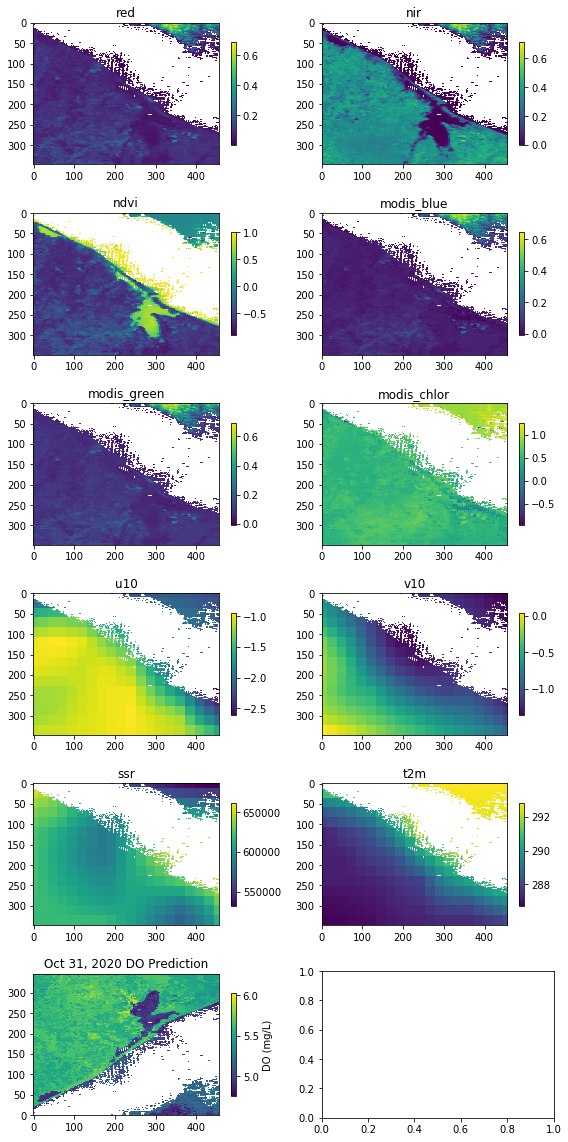

In [349]:
#want to explore inputs and prediction
H = df_oct27['lat'].nunique()
W = df_oct27['lon'].nunique()

f_plot = ['red', 'nir', 'ndvi', 'modis_blue', 'modis_green','modis_chlor', 'u10','v10', 'ssr', 't2m']

n = len(f_plot)
cols = 2
rows = int(np.ceil((n+1) / cols))

#for reshaping
df_oct27_clean_with_coords = df_oct27_clean.copy()
df_oct27_clean_with_coords['lat'] = df_oct27['lat'].values
df_oct27_clean_with_coords['lon'] = df_oct27['lon'].values

fig, axes = plt.subplots(rows, cols, figsize=(8, 16))
axes = axes.flatten()

for i, f in enumerate(f_plot):
    # reshape each feature into H×W grid
    #grid = df_sep6_clean[f].values.reshape(H, W)
    grid = df_oct27_clean_with_coords.pivot(index='lat', columns='lon', values=f).values

    im = axes[i].imshow(grid, cmap='viridis')
    axes[i].set_title(f)
    #axes[i].axis('off')
    fig.colorbar(im, ax=axes[i], shrink=0.7)

#try predict with the grid of jan 10 2020 data
y_pred_oct = final_rfr.predict(df_oct27_clean)
df_oct27_clean_with_coords['pred_DO'] = y_pred_oct
pred_grid_oct = df_oct27_clean_with_coords.pivot(
    index='lat', columns='lon', values='pred_DO').values
#y_pred_grid = y_pred.reshape(H, W)

im_pred = axes[n].imshow(pred_grid_oct, cmap='viridis', origin='lower')
axes[n].set_title("Oct 31, 2020 DO Prediction")
fig.colorbar(im_pred, ax=axes[n], shrink=0.7, label='DO (mg/L)')

plt.tight_layout()
plt.show()

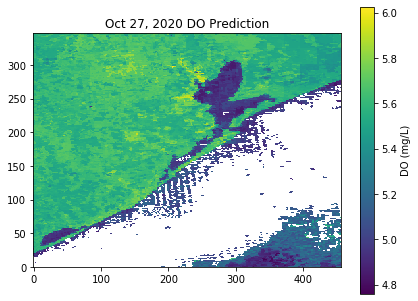

In [170]:
H = df_oct27['lat'].nunique()
W = df_oct27['lon'].nunique()

# Prepare dataframe with lat/lon for pivoting
df_oct27_clean_with_coords = df_oct27_clean.copy()
df_oct27_clean_with_coords['lat'] = df_oct27['lat'].values
df_oct27_clean_with_coords['lon'] = df_oct27['lon'].values

# Predict DO
y_pred = final_rfr.predict(df_oct27_clean)
df_oct27_clean_with_coords['pred_DO'] = y_pred

# Create grid for plotting
pred_grid_oct = df_oct27_clean_with_coords.pivot(
    index='lat', columns='lon', values='pred_DO'
).values

fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(pred_grid, cmap='viridis', origin='lower')
ax.set_title("Oct 31, 2020 DO Prediction")

cbar = fig.colorbar(im, ax=ax, shrink=0.7, label='DO (mg/L)')

plt.tight_layout()
plt.show()


In [190]:
#just looking at the locations that match the locations of the target
# Copy the dataframes
df1 = df_sep6.copy()       
df2 = X_og.copy()       

# Round coordinates for matching
df1['lat_r'] = df1['lat'].round(2)
df1['lon_r'] = df1['lon'].round(2)

df2['lat_r'] = df2[' lat'].round(2)
df2['lon_r'] = df2[' lon'].round(2)

#Build mask of matching locations
mask = df1.set_index(['lat_r', 'lon_r']).index.isin(
        df2.set_index(['lat_r', 'lon_r']).index)

# Extract the matching lat/lon rows
sep_locs = df1[mask].copy()

# Keep the rounded coordinates as the final lat/lon
sep_locs['lat'] = sep_locs['lat_r']
sep_locs['lon'] = sep_locs['lon_r']

# Step 5: Apply the SAME mask to the clean dataframe
# df_may29_clean has no lat/lon and is in correct feature order)
sep_clean_for_pred = df_sep6_clean.loc[mask].copy()

# Step 6: Predict using the clean dataframe
y_pred_sep_tl = final_rfr.predict(sep_clean_for_pred)

# Step 7: Attach predictions back to the lat/lon dataframe
sep_locs['pred_DO'] = y_pred_sep_tl

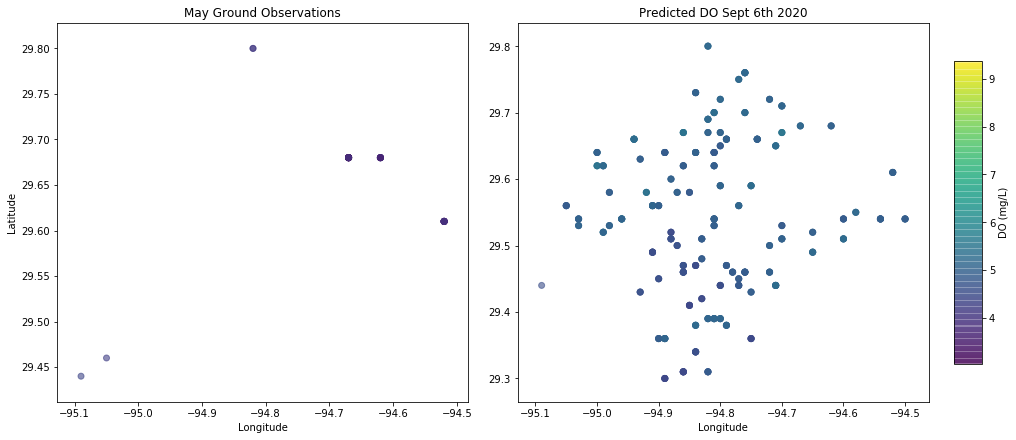

In [192]:
#comapring just the points in the same month
idx_sep = X_og[X_og[' month'] == 9].index
x_sep = X_og[X_og[' month'] == 9]
y_sep = y.loc[idx_sep]
y_sep.describe()

vmin = min(y_may['ground_obs'].min(), y_pred_allX.min())
vmax = max(y_may['ground_obs'].max(), y_pred_allX.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

#Ground Observations
sc1 = axes[0].scatter(
    x_sep[' lon'], x_sep[' lat'],
    c=y_sep['ground_obs'],
    cmap='viridis',
    vmin=vmin, vmax=vmax,
    alpha=0.6)
axes[0].set_title("Sept Ground Observations")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

#Predictions at matched may 29 locations
sc2 = axes[1].scatter(
    sep_locs['lon'], sep_locs['lat'],
    c=y_pred_sep_tl,
    cmap='viridis',
    vmin=vmin, vmax=vmax,
    alpha=0.6)
axes[1].set_title("Predicted DO Sept 6th 2020")
axes[1].set_xlabel("Longitude")

# shared colorbar
cbar = fig.colorbar(sc2, ax=axes, location='right', shrink=0.8, pad=0.02)
cbar.set_label("DO (mg/L)")

plt.show()

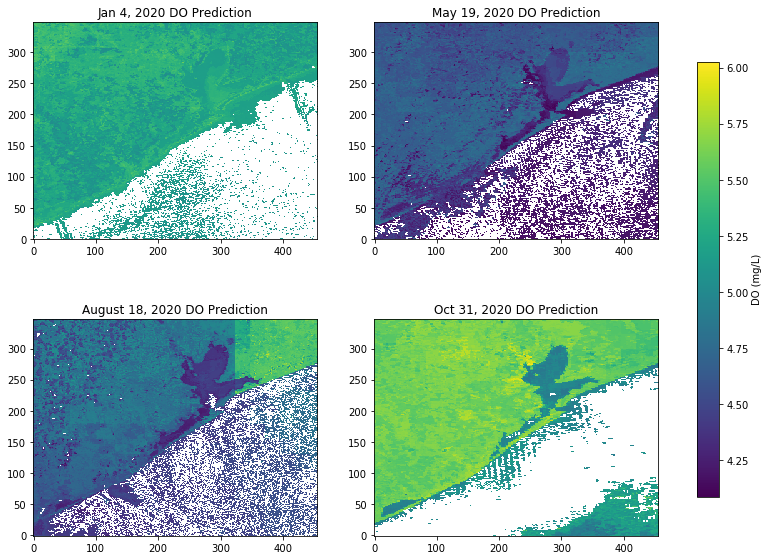

In [358]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

vmin = min(y_pred_jan.min(), y_pred_may.min(), y_pred_aug.min(), y_pred_oct.min())
vmax = max(y_pred_jan.max(), y_pred_may.max(), y_pred_aug.max(), y_pred_oct.max())

# Plot all four panels and store last image handle
im = axes[0,0].imshow(pred_grid_jan, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)
axes[0,0].set_title("Jan 4, 2020 DO Prediction")

axes[0,1].imshow(pred_grid_may, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)
axes[0,1].set_title("May 19, 2020 DO Prediction")

axes[1,0].imshow(pred_grid_aug, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)
axes[1,0].set_title("August 18, 2020 DO Prediction")

axes[1,1].imshow(pred_grid_oct, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)
axes[1,1].set_title("Oct 31, 2020 DO Prediction")

# --- ONE COLORBAR FOR ALL AXES ---
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label='DO (mg/L)')

plt.show()


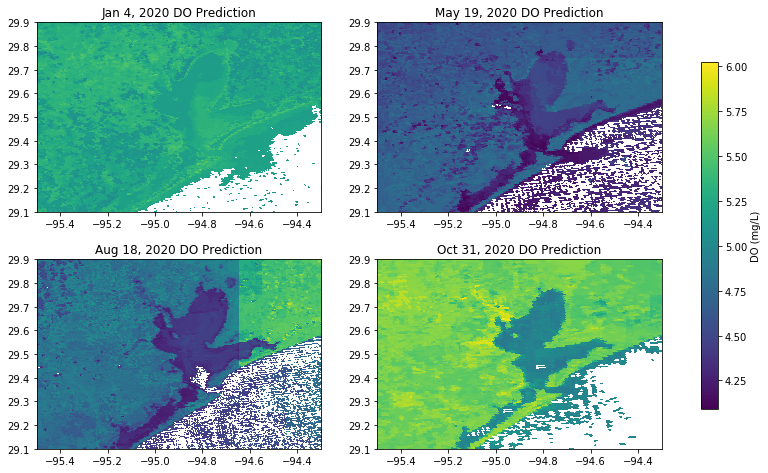

In [363]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

vmin = min(y_pred_jan.min(), y_pred_may.min(), y_pred_aug.min(), y_pred_oct.min())
vmax = max(y_pred_jan.max(), y_pred_may.max(), y_pred_aug.max(), y_pred_oct.max())

# Zoom bounds (Galveston Bay)
lon_min, lon_max = -95.5, -94.3
lat_min, lat_max = 29.1, 29.9

# ---- JAN ----
im = axes[0,0].imshow(
    pred_grid_jan,
    cmap='viridis',
    origin='lower',
    vmin=vmin, vmax=vmax,
    extent=[lon_jan.min(), lon_jan.max(), lat_jan.min(), lat_jan.max()]
)
axes[0,0].set_title("Jan 4, 2020 DO Prediction")
axes[0,0].set_xlim(lon_min, lon_max)
axes[0,0].set_ylim(lat_min, lat_max)

# ---- MAY ----
axes[0,1].imshow(
    pred_grid_may, cmap='viridis', origin='lower',
    vmin=vmin, vmax=vmax,
    extent=[lon_may.min(), lon_may.max(), lat_may.min(), lat_may.max()]
)
axes[0,1].set_title("May 19, 2020 DO Prediction")
axes[0,1].set_xlim(lon_min, lon_max)
axes[0,1].set_ylim(lat_min, lat_max)

# ---- AUG ----
axes[1,0].imshow(
    pred_grid_aug, cmap='viridis', origin='lower',
    vmin=vmin, vmax=vmax,
    extent=[lon_aug.min(), lon_aug.max(), lat_aug.min(), lat_aug.max()]
)
axes[1,0].set_title("Aug 18, 2020 DO Prediction")
axes[1,0].set_xlim(lon_min, lon_max)
axes[1,0].set_ylim(lat_min, lat_max)

# ---- OCT ----
axes[1,1].imshow(
    pred_grid_oct, cmap='viridis', origin='lower',
    vmin=vmin, vmax=vmax,
    extent=[lon_oct.min(), lon_oct.max(), lat_oct.min(), lat_oct.max()]
)
axes[1,1].set_title("Oct 31, 2020 DO Prediction")
axes[1,1].set_xlim(lon_min, lon_max)
axes[1,1].set_ylim(lat_min, lat_max)

# Shared colorbar
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label="DO (mg/L)")

#plt.tight_layout()
plt.show()


### code below has packages not imported into the container- if we want to use them, we should talk to Nate about importing them, but I don't think we really need to use them

In [ ]:
### Model 6: Generalized Additive Model

In [83]:
import numpy as np
from functools import reduce
import operator
from pygam import LinearGAM, s
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import math
import matplotlib.pyplot as plt

In [84]:
# --- prepare terms ---
n_features = X.shape[1]
terms_list = (s(i) for i in range(n_features))
terms = reduce(operator.add, terms_list)   # TermList

# --- param grid (tune these to control total # fits) ---
# Keep sizes small if n_splits is large. Example below: 6 * 3 = 18 combos per fold.
#lams  =   np.logspace(-3, 3, 10)
lams = np.random.rand(100, 5) # random points on [0, 1], with shape (100, 3)
lams = lams * 6 - 3 # shift values to -3, 3
lams = 10 ** lams # transforms values to 1e-3, 1e3
# --- TimeSeries CV + GAM gridsearch per-fold ---
tscv = TimeSeriesSplit(n_splits=12)

r2_vals, rmse_vals, mae_vals, mse_train_vals = [], [], [], []
last_fitted_gam = None
last_scaler = None

for fold, (train_idx, valid_idx) in enumerate(tscv.split(X), start=1):
    X_train, X_valid = X[train_idx], X[valid_idx]
    y_train, y_valid = y[train_idx], y[valid_idx]

    scaler = StandardScaler().fit(X_train)
    X_tr_s = scaler.transform(X_train)
    X_val_s = scaler.transform(X_valid)
    
    # Create the gam and run gridsearch ON THE TRAINING DATA only
    gam = LinearGAM(terms)
    gam = gam.gridsearch(X_tr_s, y_train, lam=lams, progress=False)

    # Now predict (do NOT call gridsearch on the validation set)
    y_pred_val = gam.predict(X_val_s)
    y_pred_train = gam.predict(X_tr_s)

    r2 = r2_score(y_valid, y_pred_val)
    rmse = np.sqrt(mean_squared_error(y_valid, y_pred_val))
    mae = mean_absolute_error(y_valid, y_pred_val)
    mse_train = mean_squared_error(y_train, y_pred_train)

    r2_vals.append(r2); rmse_vals.append(rmse); mae_vals.append(mae); mse_train_vals.append(mse_train)

    print(f"Fold {fold}: R2={r2:.4f}, RMSE={rmse:.4f}, MAE={mae:.4f}, train MSE={mse_train:.4f}")

    last_fitted_gam = gam
    last_scaler = scaler

print("Mean valid R2:   ", np.mean(r2_vals))
print("Mean valid RMSE: ", np.mean(rmse_vals))
print("Mean valid MAE:  ", np.mean(mae_vals))
print("Mean train MSE:  ", np.mean(mse_train_vals))

# --- Final refit on all data using the same (or a slightly expanded) grid ---
scaler_all = StandardScaler().fit(X)
X_all_s = scaler_all.transform(X)
gam_final = LinearGAM(terms).gridsearch(X_all_s, y, lam=lams, progress=False)

In [82]:
# --- Partial dependence plots for each feature (3-row layout) ---
n_rows = 3
n_cols = math.ceil(n_features / n_rows)
fig, axs = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axs = axs.flatten()

for i in range(n_features):
    ax = axs[i]
    XX = gam_final.generate_X_grid(term=i)
    # partial_dependence can return (pdep) or (pdep, conf) depending on args / version:
    # Trying to retrieve pdep and confidence interval safely:
    try:
        pdep = gam_final.partial_dependence(term=i, X=XX)
        # confidence interval using partial_dependence with width (some pygam versions return a tuple)
        pd_with_ci = gam_final.partial_dependence(term=i, X=XX, width=0.95)
        if isinstance(pd_with_ci, tuple) and len(pd_with_ci) == 2:
            pdep, conf = pd_with_ci
            lower, upper = conf[:, 0], conf[:, 1]
        else:
            # if width not supported or returns only pdep, compute CI via prediction_intervals
            lower, upper = gam_final.prediction_intervals(XX, width=0.95).T
    except TypeError:
        # fallback if width argument unavailable
        pdep = gam_final.partial_dependence(term=i, X=XX)
        lower, upper = gam_final.prediction_intervals(XX, width=0.95).T

    ax.plot(XX[:, i], pdep, label='partial')
    ax.plot(XX[:, i], lower, ls='--', label='95% CI')
    ax.plot(XX[:, i], upper, ls='--')
    title = feature_names[i] if ('feature_names' in globals() and i < len(feature_names)) else f"term_{i}"
    ax.set_title(title)
    ax.grid(True)

# Hide any empty subplots if n_features isn’t a multiple of n_rows
for j in range(n_features, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

In [ ]:
### Model 7: Explaianbel Boostign Machine

In [79]:
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from interpret.glassbox import ExplainableBoostingRegressor
from interpret import show

In [85]:
#n_splits = 5
#test_size = 24  # 1 day of hourly data per fold
tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)

# ----------------------------------------------------
# Function to evaluate a model using time-series CV
# ----------------------------------------------------
def eval_model(model, X, y, name="model"):
    fold_scores = []
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        fold_scores.append((r2, rmse))
        print(f"{name} | Fold {fold}: R2={r2:.3f}, RMSE={rmse:.3f}")
    mean_r2 = np.mean([r for r,_ in fold_scores])
    mean_rmse = np.mean([rm for _,rm in fold_scores])
    print(f"\n{name} | Mean R²={mean_r2:.3f}, RMSE={mean_rmse:.3f}\n")
    return model, mean_r2, mean_rmse


ebm = ExplainableBoostingRegressor(
    interactions='2x',  
    inner_bags = 0,
    learning_rate=0.04,
    interaction_smoothing_rounds =1000,
    max_leaves = 2,
    random_state=15, 
    smoothing_rounds = 1500
)
ebm, ebm_r2, ebm_rmse = eval_model(ebm, X, y, name="EBM")

print(f"EBM mean R²={ebm_r2:.3f}, RMSE={ebm_rmse:.3f}")

#explainability summary
ebm.fit(X, y)
ebm_global = ebm.explain_global(name='EBM Feature Effects')
show(ebm_global)  # interactive plots: feature vs partial dependence